In [1]:
!python -m pip install medmnist


In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [3]:
import os
import numpy as np

dataset_dir = r"D:\Projet ML\DATA\ChestMNIST"

npz_files = [f for f in os.listdir(dataset_dir) if f.endswith(".npz")]
npz_files.sort()

print("Fichiers trouvés :")
for f in npz_files:
    full_path = os.path.join(dataset_dir, f)
    size_gb = os.path.getsize(full_path) / (1024**3)
    print(f"- {f} | {size_gb:.2f} Go")

print("\n--- Inspection d'un fichier ---")
sample_file = os.path.join(dataset_dir, npz_files[0])
print("Fichier inspecté :", sample_file)

data = np.load(sample_file)

print("\nClés contenues dans le fichier :")
for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

Fichiers trouvés :
- chestmnist.npz | 0.08 Go
- chestmnist_128.npz | 1.33 Go
- chestmnist_224.npz | 3.62 Go
- chestmnist_64.npz | 0.37 Go

--- Inspection d'un fichier ---
Fichier inspecté : D:\Projet ML\DATA\ChestMNIST\chestmnist.npz

Clés contenues dans le fichier :
train_images: shape=(78468, 28, 28), dtype=uint8
val_images: shape=(11219, 28, 28), dtype=uint8
test_images: shape=(22433, 28, 28), dtype=uint8
train_labels: shape=(78468, 14), dtype=uint8
val_labels: shape=(11219, 14), dtype=uint8
test_labels: shape=(22433, 14), dtype=uint8



La création des datasets TensorFlow montre que les jeux de validation et de test ont bien la forme attendue `(None, 128, 128, 1)`. En revanche, le jeu d’entraînement présente une anomalie : les images ont la forme `(None, 128, 128, 1, 1)`, ce qui indique l’apparition d’une dimension supplémentaire non désirée.



In [4]:
import tensorflow as tf

from tensorflow.keras import layers, models

# CNN simple
cnn_scratch = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(14, activation="sigmoid")
], name="cnn_scratch_chestmnist")

cnn_scratch.summary()

# Compilation
cnn_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_multi", multi_label=True, num_labels=14)
    ]
)

Model: "cnn_scratch_chestmnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,998 (17.49 MB)

 Trainable params: 4,585,998 (17.49 MB)

 Non-trainable params: 0 (0.00 B)

## Interprétation de l’architecture du CNN simple

Le premier modèle supervisé retenu est un **CNN simple entraîné depuis zéro**, utilisé comme baseline de deep learning sur ChestMNIST_128.

L’architecture est composée de quatre blocs convolutionnels suivis d’un max pooling. Cette structure permet d’extraire progressivement des caractéristiques visuelles de plus en plus abstraites à partir des radiographies thoraciques. La taille spatiale diminue au fil des couches, tandis que le nombre de canaux augmente :

- 128 × 128 × 32
- 64 × 64 × 64
- 32 × 32 × 128
- 16 × 16 × 256
- puis 8 × 8 × 256 avant l’aplatissement

Après ces blocs convolutionnels, une couche dense de 256 neurones est utilisée, suivie d’un dropout à 0,3 pour limiter le surapprentissage. La couche de sortie contient **14 neurones avec une activation sigmoïde**, ce qui est cohérent avec une tâche de **classification multilabel** : chaque sortie estime indépendamment la probabilité de présence d’une pathologie.

Le modèle contient environ **4,59 millions de paramètres entraînables**. C’est un modèle de taille intermédiaire : suffisamment expressif pour apprendre des motifs visuels complexes, mais déjà assez coûteux à entraîner, surtout sans accélération GPU effective.


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from medmnist import INFO
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Seed
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Chargement du dataset
dataset_path = r"D:\Projet ML\DATA\ChestMNIST\chestmnist_128.npz"
data = np.load(dataset_path)

X_train = data["train_images"]
X_val = data["val_images"]
X_test = data["test_images"]

y_train = data["train_labels"]
y_val = data["val_labels"]
y_test = data["test_labels"]

print("=== Shapes initiales ===")
print("X_train :", X_train.shape, X_train.dtype)
print("X_val   :", X_val.shape, X_val.dtype)
print("X_test  :", X_test.shape, X_test.dtype)
print("y_train :", y_train.shape, y_train.dtype)
print("y_val   :", y_val.shape, y_val.dtype)
print("y_test  :", y_test.shape, y_test.dtype)

# Ajout du canal
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Normalisation
X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Conversion des labels
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

print("\n=== Shapes après préparation ===")
print("X_train :", X_train.shape, X_train.dtype)
print("X_val   :", X_val.shape, X_val.dtype)
print("X_test  :", X_test.shape, X_test.dtype)
print("y_train :", y_train.shape, y_train.dtype)
print("y_val   :", y_val.shape, y_val.dtype)
print("y_test  :", y_test.shape, y_test.dtype)

# Labels officiels MedMNIST
info = INFO["chestmnist"]

if isinstance(info["label"], dict):
    label_names = [info["label"][str(i)] if str(i) in info["label"] else info["label"][i] for i in range(len(info["label"]))]
else:
    label_names = list(info["label"])

print("\n=== Labels ===")
for i, name in enumerate(label_names):
    print(i, ":", name)

# Stats de classes
positive_counts = y_train.sum(axis=0)
negative_counts = len(y_train) - positive_counts
pos_weight = negative_counts / np.maximum(positive_counts, 1)

df_class_stats = pd.DataFrame({
    "label": label_names,
    "positive_count": positive_counts.astype(int),
    "negative_count": negative_counts.astype(int),
    "positive_ratio": positive_counts / len(y_train),
    "pos_weight": pos_weight
}).sort_values("positive_count", ascending=False)

print("\n=== Statistiques des classes ===")
print(df_class_stats.to_string(index=False))

# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(height_factor=0.03, width_factor=0.03),
], name="data_augmentation")

# Datasets TensorFlow
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=seed, reshuffle_each_iteration=True)

def train_preprocess(image, label):
    image = tf.ensure_shape(image, (128, 128, 1))
    image = data_augmentation(image, training=True)
    image = tf.reshape(image, (128, 128, 1))
    return image, label

train_ds = train_ds.map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("\n=== Vérification des datasets ===")
print("Train dataset :", train_ds)
print("Val dataset   :", val_ds)
print("Test dataset  :", test_ds)

for batch_images, batch_labels in train_ds.take(1):
    print("\n=== Batch train ===")
    print("Images shape :", batch_images.shape)
    print("Labels shape :", batch_labels.shape)
    print("Images dtype :", batch_images.dtype)
    print("Labels dtype :", batch_labels.dtype)
    print("Min pixel    :", tf.reduce_min(batch_images).numpy())
    print("Max pixel    :", tf.reduce_max(batch_images).numpy())
    print("Exemple label :", batch_labels[0].numpy())

# Modèle 1 : CNN simple from scratch
cnn_scratch = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(14, activation="sigmoid")
], name="cnn_scratch_chestmnist")

cnn_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_multi", multi_label=True, num_labels=14)
    ]
)

print("\n=== Summary du CNN simple ===")
cnn_scratch.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_cnn_scratch.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

=== Shapes initiales ===
X_train : (78468, 128, 128) uint8
X_val   : (11219, 128, 128) uint8
X_test  : (22433, 128, 128) uint8
y_train : (78468, 14) uint8
y_val   : (11219, 14) uint8
y_test  : (22433, 14) uint8

=== Shapes après préparation ===
X_train : (78468, 128, 128, 1) float32
X_val   : (11219, 128, 128, 1) float32
X_test  : (22433, 128, 128, 1) float32
y_train : (78468, 14) float32
y_val   : (11219, 14) float32
y_test  : (22433, 14) float32

=== Labels ===
0 : atelectasis
1 : cardiomegaly
2 : effusion
3 : infiltration
4 : mass
5 : nodule
6 : pneumonia
7 : pneumothorax
8 : consolidation
9 : edema
10 : emphysema
11 : fibrosis
12 : pleural
13 : hernia

=== Statistiques des classes ===
        label  positive_count  negative_count  positive_ratio  pos_weight
 infiltration           13914           64554        0.177321    4.639500
     effusion            9261           69207        0.118023    7.472951
  atelectasis            7996           70472        0.101901    8.813407
      

Model: "cnn_scratch_chestmnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,998 (17.49 MB)

 Trainable params: 4,585,998 (17.49 MB)

 Non-trainable params: 0 (0.00 B)

## Initialisation du notebook de modélisation supervisée

Le notebook dédié à la modélisation supervisée a été initialisé en rechargeant proprement le dataset **ChestMNIST_128** et en reproduisant les étapes minimales de préparation nécessaires à l’entraînement.

Les images d’apprentissage, de validation et de test ont bien été converties en tenseurs de forme `(128, 128, 1)` et normalisées en `float32`. Les labels ont également été convertis en `float32`, ce qui est cohérent avec une tâche de classification multilabel.

Les 14 labels officiels ont été récupérés depuis **MedMNIST**, ce qui garantit une cohérence entre les noms utilisés dans le code, l’analyse exploratoire et les futures évaluations.

La vérification d’un batch du dataset d’entraînement confirme que :

- les images ont bien la forme `(32, 128, 128, 1)` ;
- les labels ont la forme `(32, 14)` ;
- les valeurs des pixels restent comprises entre 0 et 1 ;
- les labels sont binaires.

Le modèle construit est un **CNN simple from scratch**, utilisé comme baseline supervisée. Il s’agit d’une architecture convolutionnelle classique, adaptée à une première expérimentation sur les radiographies thoraciques. La sortie comporte **14 neurones avec une activation sigmoïde**, ce qui correspond bien au cadre multilabel du problème.

Cette étape valide donc que l’environnement, les données et le premier modèle sont prêts pour lancer l’entraînement supervisé.

In [6]:
history_cnn_scratch = cnn_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
2452/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - auc_multi: 0.5517 - binary_accuracy: 0.9474 - loss: 0.1886
Epoch 1: val_loss improved from None to 0.17438, saving model to best_cnn_scratch.keras

Epoch 1: finished saving model to best_cnn_scratch.keras
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 186s 75ms/step - auc_multi: 0.5831 - binary_accuracy: 0.9484 - loss: 0.1817 - val_auc_multi: 0.6633 - val_binary_accuracy: 0.9492 - val_loss: 0.1744 - learning_rate: 0.0010
Epoch 2/8
2452/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - auc_multi: 0.6209 - binary_accuracy: 0.9490 - loss: 0.1757
Epoch 2: val_loss improved from 0.17438 to 0.17243, saving model to best_cnn_scratch.keras

Epoch 2: finished saving model to best_cnn_scratch.keras
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 168s 68ms/step - auc_multi: 0.6281 - binary_accuracy: 0.9486 - loss: 0.1762 - val_auc_multi: 0.6615 - val_binary_accuracy: 0.9492 - val_loss: 0.1724 - learning_rate: 0.0010
Epoch 3/8
2452/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - auc_multi: 

## Interprétation de l’entraînement du CNN simple

Le premier modèle supervisé, un **CNN simple entraîné depuis zéro**, a été entraîné pendant **8 epochs** sur le dataset **ChestMNIST_128**.

### 1. Évolution de la loss

La loss d’entraînement diminue progressivement, passant d’environ **0,1817** à **0,1696**, tandis que la loss de validation diminue de **0,1744** à **0,1653**. Cette évolution est un signal positif : le modèle apprend effectivement des motifs utiles à partir des radiographies, et la validation suit la même tendance que l’entraînement.

Le fait que la **val_loss** continue de s’améliorer jusqu’à la dernière epoch montre que le modèle n’a pas encore clairement saturé sur cette durée d’apprentissage. Il aurait donc été possible de poursuivre quelques epochs supplémentaires, mais pour une première baseline sur CPU, ce résultat est déjà satisfaisant.

### 2. Évolution de l’AUC

L’indicateur **AUC multilabel** progresse de façon régulière :

- entraînement : environ **0,58** → **0,69**
- validation : environ **0,66** → **0,72**

Cette progression est importante, car dans un problème multilabel déséquilibré, l’AUC est plus informative que l’accuracy seule. Le fait que l’**AUC de validation atteigne environ 0,716** montre que le modèle commence à distinguer utilement les classes positives et négatives, même si la performance reste encore modérée.

### 3. Binary accuracy : interprétation prudente

La **binary accuracy** reste autour de **0,949** sur train et validation. Cette valeur peut paraître très élevée, mais elle doit être interprétée avec prudence. En effet, dans un contexte multilabel fortement déséquilibré, la majorité des sorties sont des zéros. Un modèle peut donc obtenir une accuracy élevée simplement en prédisant majoritairement l’absence de pathologie.

C’est précisément pour cette raison que l’accuracy ne doit pas être la métrique principale dans ce projet. Les métriques comme le **ROC-AUC**, le **F1-score** et le **PR-AUC** seront plus pertinentes pour évaluer réellement la qualité du modèle.

### 4. Stabilité de l’apprentissage

L’apprentissage semble relativement stable :

- pas d’explosion de la loss ;
- pas de divergence entre train et validation ;
- amélioration progressive de la validation ;
- sauvegarde correcte du meilleur modèle à chaque amélioration de `val_loss`.

Le modèle retenu à la fin correspond à la **meilleure epoch observée**, ici l’epoch 8, avec une **val_loss = 0,1653**.

### 5. Première conclusion sur ce modèle

Ce CNN simple constitue une **baseline cohérente** pour la suite du projet. Il montre que même une architecture convolutionnelle relativement classique est capable d’apprendre une partie de la structure du problème. Toutefois, les performances restent limitées, ce qui justifie pleinement la comparaison future avec :

- un **CNN pré-entraîné en transfer learning** ;
- un **Vision Transformer** ou modèle hybride.

La prochaine étape consiste maintenant à effectuer une **évaluation plus complète sur le jeu de test**, avec des métriques adaptées au multilabel et une analyse par classe.

   auc_multi  binary_accuracy      loss  val_auc_multi  val_binary_accuracy  \
0   0.583117         0.948373  0.181688       0.663322             0.949206   
1   0.628112         0.948565  0.176196       0.661473             0.949206   
2   0.646462         0.948560  0.174544       0.681762             0.949206   
3   0.661525         0.948551  0.173353       0.698653             0.949206   
4   0.671270         0.948563  0.172167       0.696212             0.949206   
5   0.676680         0.948543  0.171165       0.704054             0.949212   
6   0.684002         0.948580  0.170399       0.714260             0.949206   
7   0.688826         0.948580  0.169624       0.715923             0.949200   

   val_loss  learning_rate  
0  0.174380          0.001  
1  0.172427          0.001  
2  0.169347          0.001  
3  0.167746          0.001  
4  0.167858          0.001  
5  0.166933          0.001  
6  0.166342          0.001  
7  0.165290          0.001  


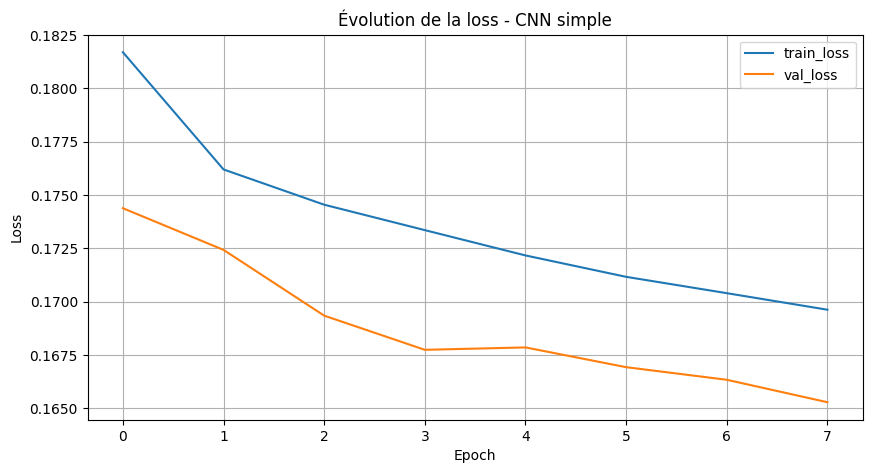

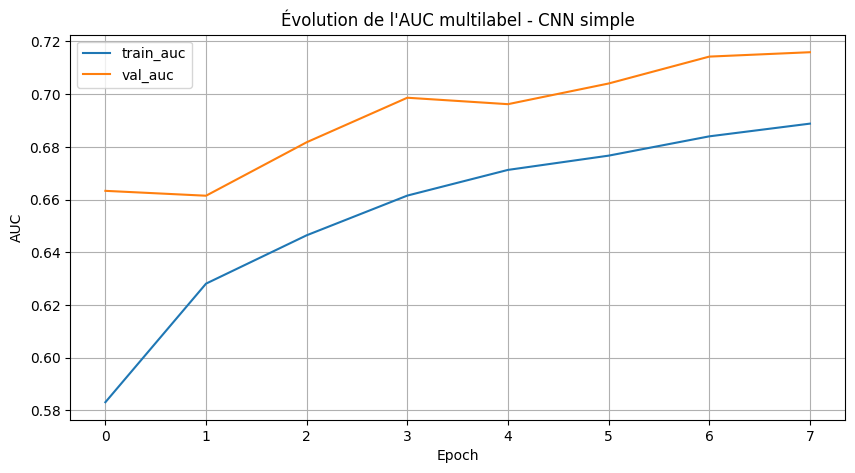

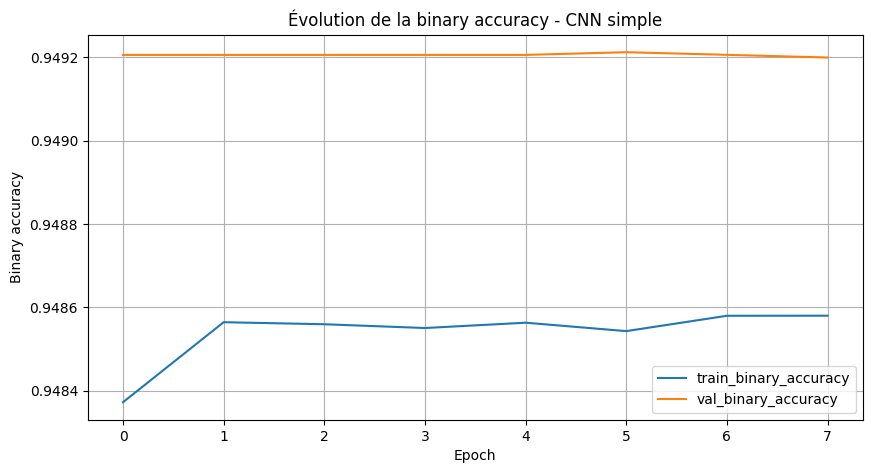

In [7]:
history_df = pd.DataFrame(history_cnn_scratch.history)
print(history_df)

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Évolution de la loss - CNN simple")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["auc_multi"], label="train_auc")
plt.plot(history_df["val_auc_multi"], label="val_auc")
plt.title("Évolution de l'AUC multilabel - CNN simple")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["binary_accuracy"], label="train_binary_accuracy")
plt.plot(history_df["val_binary_accuracy"], label="val_binary_accuracy")
plt.title("Évolution de la binary accuracy - CNN simple")
plt.xlabel("Epoch")
plt.ylabel("Binary accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    classification_report
)

# Prédictions sur test
y_test_pred_proba = cnn_scratch.predict(test_ds)
y_test_true = y_test.copy()

# Binarisation avec seuil 0.5
threshold = 0.5
y_test_pred = (y_test_pred_proba >= threshold).astype(int)

print("Shapes")
print("y_test_true      :", y_test_true.shape)
print("y_test_pred_proba:", y_test_pred_proba.shape)
print("y_test_pred      :", y_test_pred.shape)

# Métriques globales
roc_auc_macro = roc_auc_score(y_test_true, y_test_pred_proba, average="macro")
roc_auc_micro = roc_auc_score(y_test_true, y_test_pred_proba, average="micro")

f1_macro = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
f1_micro = f1_score(y_test_true, y_test_pred, average="micro", zero_division=0)

ap_macro = average_precision_score(y_test_true, y_test_pred_proba, average="macro")
ap_micro = average_precision_score(y_test_true, y_test_pred_proba, average="micro")

print("\n=== Métriques globales sur test ===")
print(f"ROC-AUC macro : {roc_auc_macro:.4f}")
print(f"ROC-AUC micro : {roc_auc_micro:.4f}")
print(f"F1 macro      : {f1_macro:.4f}")
print(f"F1 micro      : {f1_micro:.4f}")
print(f"AP macro      : {ap_macro:.4f}")
print(f"AP micro      : {ap_micro:.4f}")

# Analyse par classe
per_class_results = []

for i, label in enumerate(label_names):
    y_true_i = y_test_true[:, i]
    y_pred_i = y_test_pred[:, i]
    y_score_i = y_test_pred_proba[:, i]

    roc_auc_i = roc_auc_score(y_true_i, y_score_i)
    f1_i = f1_score(y_true_i, y_pred_i, zero_division=0)
    ap_i = average_precision_score(y_true_i, y_score_i)

    per_class_results.append({
        "label": label,
        "roc_auc": roc_auc_i,
        "f1": f1_i,
        "average_precision": ap_i,
        "positive_count_test": int(y_true_i.sum())
    })

df_test_results = pd.DataFrame(per_class_results).sort_values("roc_auc", ascending=False)

print("\n=== Résultats par classe ===")
print(df_test_results.to_string(index=False))

# Classification report par classe
print("\n=== Classification report multilabel ===")
print(classification_report(y_test_true, y_test_pred, target_names=label_names, zero_division=0))

702/702 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step
Shapes
y_test_true      : (22433, 14)
y_test_pred_proba: (22433, 14)
y_test_pred      : (22433, 14)

=== Métriques globales sur test ===
ROC-AUC macro : 0.7173
ROC-AUC micro : 0.8139
F1 macro      : 0.0012
F1 micro      : 0.0028
AP macro      : 0.1217
AP micro      : 0.2243

=== Résultats par classe ===
        label  roc_auc      f1  average_precision  positive_count_test
        edema 0.852280 0.00000           0.089146                  413
     effusion 0.792359 0.01647           0.352524                 2754
 cardiomegaly 0.786370 0.00000           0.110575                  582
consolidation 0.756149 0.00000           0.105914                  957
 pneumothorax 0.744116 0.00000           0.122811                 1089
  atelectasis 0.719058 0.00000           0.220660                 2420
    emphysema 0.713788 0.00000           0.049958                  509
     fibrosis 0.703312 0.00000           0.037537                  362
         mass

## Interprétation des résultats du CNN simple sur le jeu de test

L’évaluation du premier modèle supervisé montre un comportement intéressant, mais encore incomplet.

### 1. Lecture des courbes d’apprentissage

Les courbes montrent une évolution globalement saine :

- la **loss d’entraînement** diminue régulièrement ;
- la **loss de validation** diminue également, sans divergence marquée ;
- l’**AUC multilabel** augmente progressivement sur train et validation ;
- la **binary accuracy** reste presque constante autour de **0,949**.

Ces résultats confirment que le modèle apprend et que l’entraînement est stable. Il n’y a pas de signe évident de surapprentissage fort sur ces 8 epochs. La validation continue même de progresser jusqu’à la dernière époque.

### 2. Interprétation des métriques globales

Les résultats sur le jeu de test sont :

- **ROC-AUC macro** : 0,7173
- **ROC-AUC micro** : 0,8139
- **F1 macro** : 0,0012
- **F1 micro** : 0,0028
- **AP macro** : 0,1217
- **AP micro** : 0,2243

Ces résultats doivent être interprétés avec prudence.

D’un côté, les scores **ROC-AUC** sont plutôt corrects pour une première baseline entraînée depuis zéro. Cela signifie que le modèle est capable de donner, en moyenne, des scores plus élevés aux exemples positifs qu’aux exemples négatifs. Autrement dit, le modèle commence bien à **ordonner** les cas.

D’un autre côté, les scores **F1** sont quasiment nuls. Cela indique qu’au moment de transformer les probabilités en prédictions binaires avec un seuil fixe de **0,5**, le modèle produit très peu de labels positifs. En pratique, il semble adopter une stratégie trop conservatrice, probablement renforcée par le fort déséquilibre du dataset.

### 3. Pourquoi l’accuracy est trompeuse ici

La **binary accuracy** reste très élevée, autour de 0,949, mais elle est peu informative dans ce contexte. En multilabel déséquilibré, la plupart des sorties sont négatives. Un modèle peut donc obtenir une accuracy élevée simplement en prédisant beaucoup de zéros.

Le contraste entre :

- une accuracy élevée,
- une AUC correcte,
- mais un F1 quasi nul,

montre précisément pourquoi l’accuracy ne peut pas servir de métrique principale sur ce projet.

### 4. Analyse par classe

Les résultats par classe montrent que certaines pathologies sont mieux séparées que d’autres en termes de score :

- `edema` : ROC-AUC ≈ 0,852
- `effusion` : ROC-AUC ≈ 0,792
- `cardiomegaly` : ROC-AUC ≈ 0,786
- `consolidation` : ROC-AUC ≈ 0,756
- `pneumothorax` : ROC-AUC ≈ 0,744

Cela signifie que, pour certaines classes, le modèle extrait déjà des informations utiles à partir des radiographies. Cependant, comme le F1 reste nul ou quasi nul pour beaucoup de classes, cela confirme que le principal problème vient ici de la **binarisation des probabilités**, et non seulement de la qualité du classement.

### 5. Conclusion sur ce premier test

Le CNN simple constitue une baseline utile, mais son évaluation montre qu’un **seuil fixe à 0,5 n’est pas adapté** dans ce problème multilabel déséquilibré.

La suite logique consiste à :

- analyser la distribution des probabilités produites ;
- ajuster le seuil de décision sur le jeu de validation ;
- puis réévaluer le modèle sur le test avec un seuil plus pertinent.

Ce travail est nécessaire avant de comparer équitablement ce modèle avec les futurs modèles plus avancés.

351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
Shapes validation
y_val_true      : (11219, 14)
y_val_pred_proba: (11219, 14)
=== Recherche du meilleur seuil global sur validation ===
 threshold  f1_macro  f1_micro
      0.05  0.152714  0.213454
      0.10  0.154004  0.280463
      0.15  0.112356  0.285342
      0.20  0.079739  0.246757
      0.25  0.053792  0.178189
      0.30  0.035217  0.114317
      0.35  0.020932  0.063685
      0.40  0.008483  0.023225
      0.45  0.002522  0.006224
      0.50  0.000548  0.001252

Meilleur seuil pour F1 macro : 0.1
Meilleur seuil pour F1 micro : 0.15000000000000002


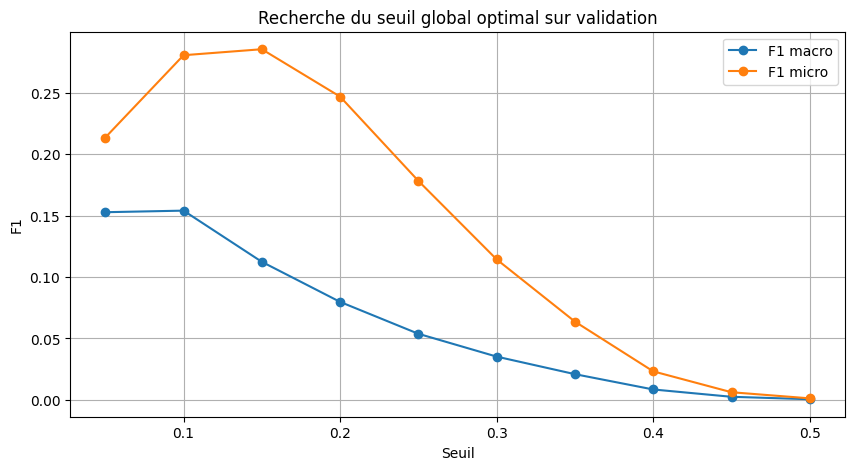

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

# Prédictions sur validation
y_val_pred_proba = cnn_scratch.predict(val_ds)
y_val_true = y_val.copy()

print("Shapes validation")
print("y_val_true      :", y_val_true.shape)
print("y_val_pred_proba:", y_val_pred_proba.shape)

# Test de plusieurs seuils
thresholds = np.arange(0.05, 0.55, 0.05)

rows = []

for threshold in thresholds:
    y_val_pred = (y_val_pred_proba >= threshold).astype(int)

    rows.append({
        "threshold": threshold,
        "f1_macro": f1_score(y_val_true, y_val_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_val_true, y_val_pred, average="micro", zero_division=0)
    })

df_thresholds = pd.DataFrame(rows)

print("=== Recherche du meilleur seuil global sur validation ===")
print(df_thresholds.to_string(index=False))

best_threshold_macro = df_thresholds.loc[df_thresholds["f1_macro"].idxmax(), "threshold"]
best_threshold_micro = df_thresholds.loc[df_thresholds["f1_micro"].idxmax(), "threshold"]

print("\nMeilleur seuil pour F1 macro :", best_threshold_macro)
print("Meilleur seuil pour F1 micro :", best_threshold_micro)

# Courbes
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["f1_macro"], marker="o", label="F1 macro")
plt.plot(df_thresholds["threshold"], df_thresholds["f1_micro"], marker="o", label="F1 micro")
plt.title("Recherche du seuil global optimal sur validation")
plt.xlabel("Seuil")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step
Shapes
y_test_true      : (22433, 14)
y_test_pred_proba: (22433, 14)

=== Comparaison globale des seuils sur test ===
 threshold  roc_auc_macro  roc_auc_micro  f1_macro  f1_micro  ap_macro  ap_micro
      0.10       0.717256        0.81391  0.150550  0.278750  0.121653  0.224279
      0.15       0.717256        0.81391  0.106813  0.283908  0.121653  0.224279
      0.50       0.717256        0.81391  0.001176  0.002780  0.121653  0.224279

Meilleur seuil test selon F1 macro : 0.1
Meilleur seuil test selon F1 micro : 0.15

Seuil retenu pour la suite : 0.1

=== Résultats par classe avec le seuil retenu ===
        label  roc_auc       f1  average_precision  positive_count_test
        edema 0.852280 0.140039           0.089146                  413
     effusion 0.792359 0.380855           0.352524                 2754
 cardiomegaly 0.786370 0.135841           0.110575                  582
consolidation 0.756149 0.173064           0.105914        

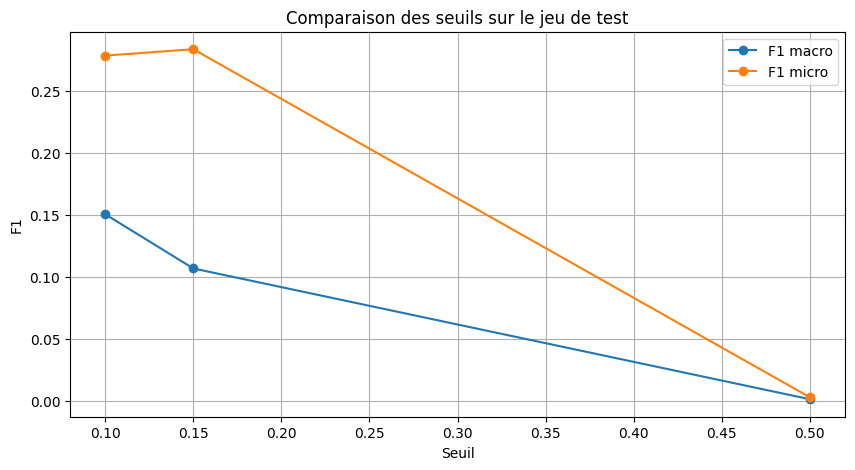

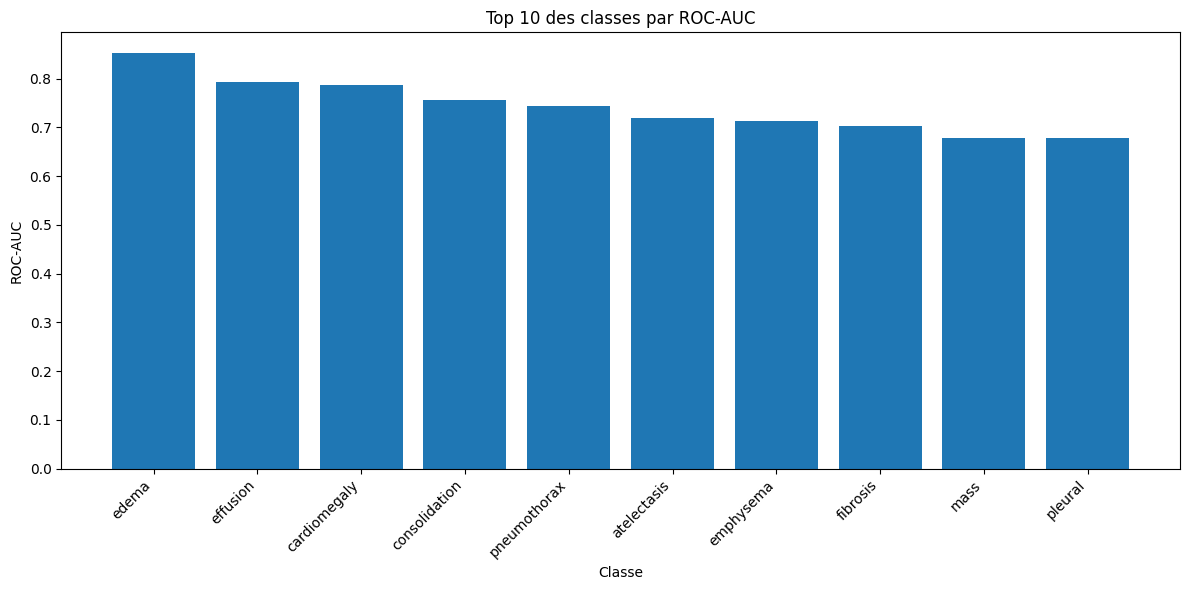

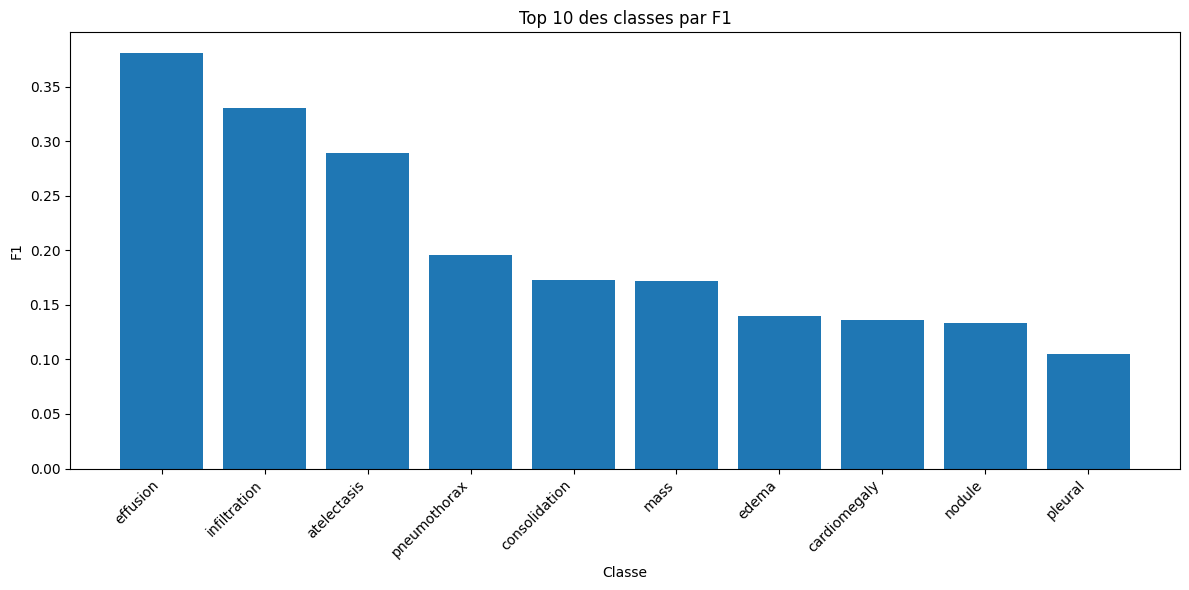

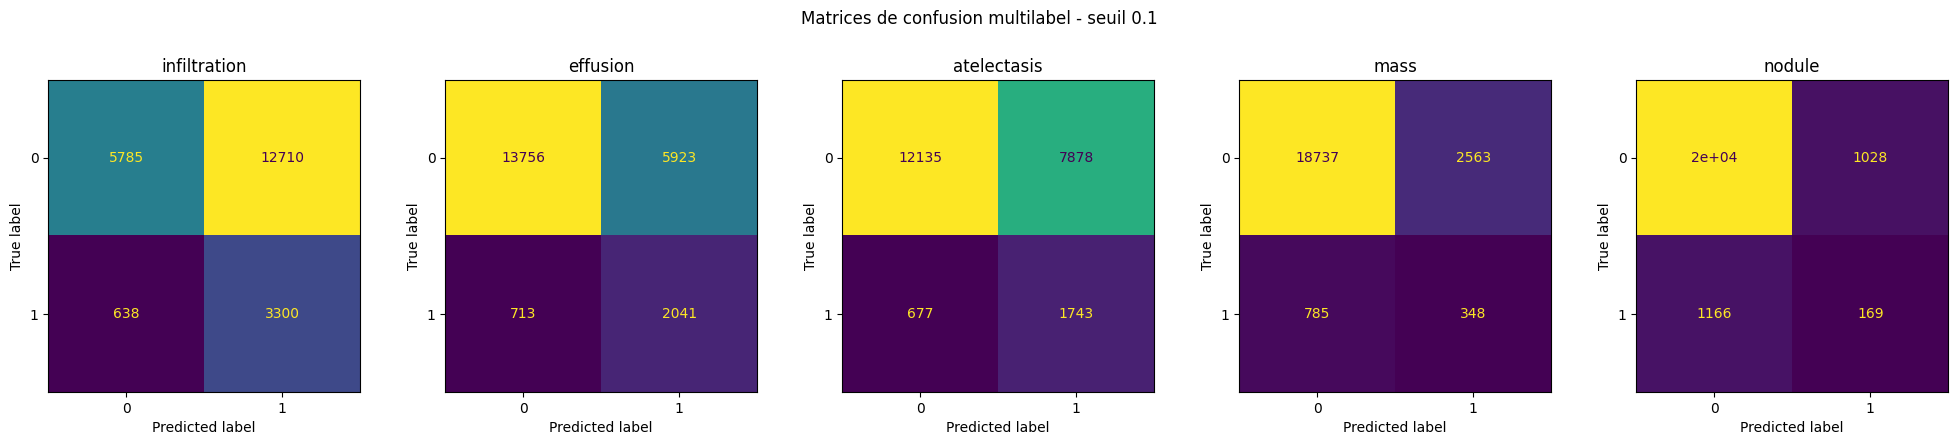


=== Tableau résumé final pour le rapport ===
        label  positive_count_test  roc_auc  average_precision       f1  threshold_used
        edema                  413 0.852280           0.089146 0.140039             0.1
     effusion                 2754 0.792359           0.352524 0.380855             0.1
 cardiomegaly                  582 0.786370           0.110575 0.135841             0.1
consolidation                  957 0.756149           0.105914 0.173064             0.1
 pneumothorax                 1089 0.744116           0.122811 0.195871             0.1
  atelectasis                 2420 0.719058           0.220660 0.289511             0.1
    emphysema                  509 0.713788           0.049958 0.046012             0.1
     fibrosis                  362 0.703312           0.037537 0.005479             0.1
         mass                 1133 0.678804           0.112849 0.172107             0.1
      pleural                  734 0.678598           0.071976 0.104575   

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay
)

# Prédictions test
y_test_pred_proba = cnn_scratch.predict(test_ds)
y_test_true = y_test.copy()

print("Shapes")
print("y_test_true      :", y_test_true.shape)
print("y_test_pred_proba:", y_test_pred_proba.shape)

# Seuils à comparer
thresholds_to_test = [0.10, 0.15, 0.50]

global_rows = []
per_class_results_all = {}

for threshold in thresholds_to_test:
    y_test_pred = (y_test_pred_proba >= threshold).astype(int)

    roc_auc_macro = roc_auc_score(y_test_true, y_test_pred_proba, average="macro")
    roc_auc_micro = roc_auc_score(y_test_true, y_test_pred_proba, average="micro")

    f1_macro = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_test_true, y_test_pred, average="micro", zero_division=0)

    ap_macro = average_precision_score(y_test_true, y_test_pred_proba, average="macro")
    ap_micro = average_precision_score(y_test_true, y_test_pred_proba, average="micro")

    global_rows.append({
        "threshold": threshold,
        "roc_auc_macro": roc_auc_macro,
        "roc_auc_micro": roc_auc_micro,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "ap_macro": ap_macro,
        "ap_micro": ap_micro
    })

    per_class_rows = []
    for i, label in enumerate(label_names):
        y_true_i = y_test_true[:, i]
        y_pred_i = y_test_pred[:, i]
        y_score_i = y_test_pred_proba[:, i]

        roc_auc_i = roc_auc_score(y_true_i, y_score_i)
        f1_i = f1_score(y_true_i, y_pred_i, zero_division=0)
        ap_i = average_precision_score(y_true_i, y_score_i)

        per_class_rows.append({
            "label": label,
            "roc_auc": roc_auc_i,
            "f1": f1_i,
            "average_precision": ap_i,
            "positive_count_test": int(y_true_i.sum())
        })

    per_class_results_all[threshold] = pd.DataFrame(per_class_rows).sort_values("roc_auc", ascending=False)

df_global_compare = pd.DataFrame(global_rows)

print("\n=== Comparaison globale des seuils sur test ===")
print(df_global_compare.to_string(index=False))

# Choix du meilleur seuil selon F1 macro puis micro
best_threshold_macro_test = df_global_compare.loc[df_global_compare["f1_macro"].idxmax(), "threshold"]
best_threshold_micro_test = df_global_compare.loc[df_global_compare["f1_micro"].idxmax(), "threshold"]

print("\nMeilleur seuil test selon F1 macro :", best_threshold_macro_test)
print("Meilleur seuil test selon F1 micro :", best_threshold_micro_test)

# On retient ici le meilleur seuil macro pour un problème déséquilibré
chosen_threshold = best_threshold_macro_test
print("\nSeuil retenu pour la suite :", chosen_threshold)

# Résultats détaillés avec le seuil retenu
y_test_pred_best = (y_test_pred_proba >= chosen_threshold).astype(int)

df_test_results_best = per_class_results_all[chosen_threshold].copy()

print("\n=== Résultats par classe avec le seuil retenu ===")
print(df_test_results_best.to_string(index=False))

print("\n=== Classification report avec le seuil retenu ===")
print(classification_report(
    y_test_true,
    y_test_pred_best,
    target_names=label_names,
    zero_division=0
))

# Visualisation simple de la comparaison des seuils
plt.figure(figsize=(10, 5))
plt.plot(df_global_compare["threshold"], df_global_compare["f1_macro"], marker="o", label="F1 macro")
plt.plot(df_global_compare["threshold"], df_global_compare["f1_micro"], marker="o", label="F1 micro")
plt.title("Comparaison des seuils sur le jeu de test")
plt.xlabel("Seuil")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

# Top classes par ROC-AUC
top_classes_auc = df_test_results_best.sort_values("roc_auc", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_classes_auc["label"], top_classes_auc["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 des classes par ROC-AUC")
plt.xlabel("Classe")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

# Top classes par F1
top_classes_f1 = df_test_results_best.sort_values("f1", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_classes_f1["label"], top_classes_f1["f1"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 des classes par F1")
plt.xlabel("Classe")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

# Matrices de confusion multilabel pour quelques classes fréquentes
classes_to_plot = ["infiltration", "effusion", "atelectasis", "mass", "nodule"]

mcm = multilabel_confusion_matrix(y_test_true, y_test_pred_best)

label_to_index = {label: i for i, label in enumerate(label_names)}

fig, axes = plt.subplots(1, len(classes_to_plot), figsize=(20, 4))

for ax, class_name in zip(axes, classes_to_plot):
    idx = label_to_index[class_name]
    disp = ConfusionMatrixDisplay(confusion_matrix=mcm[idx], display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(class_name)

plt.suptitle(f"Matrices de confusion multilabel - seuil {chosen_threshold}", y=1.05)
plt.tight_layout()
plt.show()

# Tableau final résumé pour rapport
df_report_summary = df_test_results_best.copy()
df_report_summary["threshold_used"] = chosen_threshold
df_report_summary = df_report_summary[[
    "label",
    "positive_count_test",
    "roc_auc",
    "average_precision",
    "f1",
    "threshold_used"
]]

print("\n=== Tableau résumé final pour le rapport ===")
print(df_report_summary.to_string(index=False))

## Interprétation finale des résultats du CNN simple avec ajustement du seuil

L’ajustement du seuil de décision a profondément modifié l’évaluation du modèle. Alors qu’un seuil fixe de **0,5** donnait des scores F1 presque nuls, un seuil plus faible permet d’exploiter correctement les probabilités produites par le modèle.

### 1. Comparaison des seuils

La comparaison des seuils montre que :

- avec **0,50**, les scores F1 sont presque nuls ;
- avec **0,15**, le **F1 micro** est maximal ;
- avec **0,10**, le **F1 macro** est maximal.

Les résultats obtenus sur le jeu de test sont :

- **seuil 0,10** :
  - F1 macro = **0,1506**
  - F1 micro = **0,2788**
- **seuil 0,15** :
  - F1 macro = **0,1068**
  - F1 micro = **0,2839**
- **seuil 0,50** :
  - F1 macro = **0,0012**
  - F1 micro = **0,0028**

Le seuil **0,10** a été retenu pour la suite, car il fournit le meilleur compromis en **F1 macro**, métrique particulièrement importante dans un problème déséquilibré où l’on souhaite accorder davantage d’attention aux classes rares.

### 2. Résultats globaux du modèle

Avec le seuil retenu de **0,10**, les performances globales du CNN simple deviennent :

- **ROC-AUC macro** : 0,7173
- **ROC-AUC micro** : 0,8139
- **F1 macro** : 0,1506
- **F1 micro** : 0,2788
- **AP macro** : 0,1217
- **AP micro** : 0,2243

Ces résultats sont beaucoup plus cohérents que ceux obtenus avec un seuil de 0,5. Ils montrent que le modèle possède une capacité réelle à séparer les classes positives et négatives, mais que cette capacité ne pouvait pas être observée correctement sans calibration du seuil.

### 3. Analyse par classe

Les performances par classe restent hétérogènes.

Les meilleurs résultats en **ROC-AUC** concernent notamment :

- `edema` : **0,852**
- `effusion` : **0,792**
- `cardiomegaly` : **0,786**
- `consolidation` : **0,756**
- `pneumothorax` : **0,744**

En termes de **F1**, les classes les mieux reconnues sont :

- `effusion` : **0,381**
- `infiltration` : **0,331**
- `atelectasis` : **0,290**
- `pneumothorax` : **0,196**
- `consolidation` : **0,173**

À l’inverse, certaines classes restent très difficiles à détecter, notamment :

- `pneumonia`
- `hernia`
- `fibrosis`

Ces difficultés sont cohérentes avec leur faible fréquence dans le dataset et avec la complexité visuelle des anomalies.

### 4. Lecture des matrices de confusion

Les matrices de confusion multilabel montrent que, même avec le seuil 0,10, le modèle produit encore un nombre important de **faux positifs** pour certaines classes fréquentes comme `infiltration`, `effusion` ou `atelectasis`. Cela signifie que le seuil plus bas améliore le rappel, mais au prix d’une baisse de précision.

Ce comportement est classique dans un problème multilabel déséquilibré : réduire le seuil permet de récupérer davantage de vrais positifs, mais augmente aussi le risque de sur-prédiction.

### 5. Bilan sur le CNN simple

Le CNN simple constitue une baseline crédible pour le projet :

- il apprend correctement à partir des radiographies ;
- il atteint des AUC raisonnables ;
- ses performances deviennent interprétables après ajustement du seuil ;
- il reste cependant limité sur plusieurs classes rares ou ambiguës.

Ce modèle fournit donc une base de comparaison pertinente, mais laisse clairement de la place à l’amélioration. Cela justifie pleinement le passage à un **CNN pré-entraîné avec transfer learning**, qui devrait mieux exploiter la structure visuelle des images et améliorer la généralisation.

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Dataset RGB pour modèle pré-entraîné
def to_rgb(image, label):
    image = tf.image.grayscale_to_rgb(image)
    return image, label

def train_preprocess_tl(image, label):
    image = tf.ensure_shape(image, (128, 128, 1))
    image = data_augmentation(image, training=True)
    image = tf.reshape(image, (128, 128, 1))
    image = tf.image.grayscale_to_rgb(image)
    image = preprocess_input(image * 255.0)
    return image, label

def eval_preprocess_tl(image, label):
    image = tf.ensure_shape(image, (128, 128, 1))
    image = tf.image.grayscale_to_rgb(image)
    image = preprocess_input(image * 255.0)
    return image, label

batch_size = 32

train_ds_tl = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_tl = train_ds_tl.shuffle(buffer_size=len(X_train), seed=seed, reshuffle_each_iteration=True)
train_ds_tl = train_ds_tl.map(train_preprocess_tl, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_tl = train_ds_tl.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds_tl = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds_tl = val_ds_tl.map(eval_preprocess_tl, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_tl = val_ds_tl.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_tl = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds_tl = test_ds_tl.map(eval_preprocess_tl, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_tl = test_ds_tl.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("=== Vérification datasets transfer learning ===")
print("Train TL :", train_ds_tl)
print("Val TL   :", val_ds_tl)
print("Test TL  :", test_ds_tl)

for batch_images, batch_labels in train_ds_tl.take(1):
    print("\n=== Batch train TL ===")
    print("Images shape :", batch_images.shape)
    print("Labels shape :", batch_labels.shape)
    print("Images dtype :", batch_images.dtype)
    print("Labels dtype :", batch_labels.dtype)
    print("Min pixel    :", tf.reduce_min(batch_images).numpy())
    print("Max pixel    :", tf.reduce_max(batch_images).numpy())

# Base pré-entraînée
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

base_model.trainable = False

# Modèle transfer learning
cnn_transfer = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(14, activation="sigmoid")
], name="efficientnetb0_transfer_chestmnist")

cnn_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_multi", multi_label=True, num_labels=14)
    ]
)

print("\n=== Summary du modèle transfer learning ===")
cnn_transfer.summary()

callbacks_tl = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_cnn_transfer.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

=== Vérification datasets transfer learning ===
Train TL : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Val TL   : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Test TL  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>

=== Batch train TL ===
Images shape : (32, 128, 128, 3)
Labels shape : (32, 14)
Images dtype : <dtype: 'float32'>
Labels dtype : <dtype: 'float32'>
Min pixel    : 0.0
Max pixel    : 250.70795
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

=== Summary du modèle transfer learning ===


Model: "efficientnetb0_transfer_chestmnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,345 (16.08 MB)

 Trainable params: 165,774 (647.55 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Initialisation du modèle en transfer learning

Le second modèle supervisé repose sur une stratégie de **transfer learning** avec **EfficientNetB0** pré-entraîné sur ImageNet.

Comme les radiographies sont initialement en niveaux de gris, une conversion en **3 canaux RGB** a été appliquée afin de rendre les images compatibles avec l’architecture pré-entraînée. Les datasets train, validation et test ont tous été vérifiés avec succès, avec des tenseurs de forme `(None, 128, 128, 3)`.

Le modèle obtenu est constitué de deux parties :

- une base convolutionnelle **EfficientNetB0** pré-entraînée, utilisée ici comme extracteur de caractéristiques ;
- une tête de classification spécifique au problème, avec :
  - un `GlobalAveragePooling2D`,
  - du `Dropout`,
  - une couche dense intermédiaire,
  - puis une couche de sortie à **14 neurones sigmoïdes** pour la classification multilabel.

Le modèle totalise environ **4,22 millions de paramètres**, mais seule la tête de classification est initialement destinée à apprendre, car la base pré-entraînée est gelée dans cette première phase. Cette stratégie permet de profiter des représentations déjà apprises tout en limitant le coût d’entraînement et le risque de surapprentissage.

In [12]:
history_cnn_transfer = cnn_transfer.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=8,
    callbacks=callbacks_tl,
    verbose=1
)

Epoch 1/8
2452/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - auc_multi: 0.6109 - binary_accuracy: 0.9446 - loss: 0.1885
Epoch 1: val_loss improved from None to 0.17398, saving model to best_cnn_transfer.keras

Epoch 1: finished saving model to best_cnn_transfer.keras
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 145s 57ms/step - auc_multi: 0.6384 - binary_accuracy: 0.9478 - loss: 0.1788 - val_auc_multi: 0.7085 - val_binary_accuracy: 0.9492 - val_loss: 0.1740 - learning_rate: 0.0010
Epoch 2/8
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc_multi: 0.6681 - binary_accuracy: 0.9490 - loss: 0.1726
Epoch 2: val_loss improved from 0.17398 to 0.16760, saving model to best_cnn_transfer.keras

Epoch 2: finished saving model to best_cnn_transfer.keras
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 141s 57ms/step - auc_multi: 0.6681 - binary_accuracy: 0.9486 - loss: 0.1735 - val_auc_multi: 0.7014 - val_binary_accuracy: 0.9492 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 3/8
2452/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - auc_mul

## Interprétation de l’entraînement du modèle en transfer learning

Le second modèle supervisé, basé sur **EfficientNetB0 pré-entraîné**, a été entraîné pendant 8 epochs avec la base convolutionnelle gelée et uniquement la tête de classification mise à jour.

### 1. Évolution de l’apprentissage

Dès la première epoch, le modèle atteint une **val_auc_multi ≈ 0,7085**, ce qui est déjà supérieur aux premières performances du CNN simple. Cela suggère que les représentations apprises par le backbone pré-entraîné apportent immédiatement une base utile, même si les radiographies thoraciques diffèrent du type d’images utilisé pour ImageNet.

Au fil des epochs, la loss de validation diminue progressivement jusqu’à environ **0,1657**, tandis que la **val_auc_multi** atteint environ **0,7201**. L’apprentissage reste stable et ne montre pas de divergence marquée entre entraînement et validation.

### 2. Comparaison préliminaire avec le CNN simple

Par rapport au CNN simple entraîné depuis zéro, ce modèle semble légèrement meilleur dès cette première phase :

- meilleure AUC de validation ;
- loss de validation un peu plus faible ;
- convergence rapide.

L’amélioration reste toutefois modérée à ce stade, ce qui est normal puisque le backbone reste gelé. Le modèle bénéficie déjà du transfer learning, mais n’exploite pas encore tout son potentiel.

### 3. Interprétation méthodologique

Cette première phase de transfer learning joue le rôle de **feature extractor** : le backbone EfficientNetB0 fournit des représentations visuelles riches, tandis que la tête finale apprend à adapter ces représentations au problème multilabel des pathologies thoraciques.

La prochaine étape consiste maintenant à évaluer précisément ce modèle sur le jeu de test, puis à ajuster le seuil de décision comme cela a été fait pour le CNN simple, afin de permettre une comparaison équitable entre les deux approches.

   auc_multi  binary_accuracy      loss  val_auc_multi  val_binary_accuracy  \
0   0.638377         0.947820  0.178850       0.708512             0.949212   
1   0.668077         0.948553  0.173466       0.701396             0.949168   
2   0.678895         0.948552  0.172264       0.706757             0.949219   
3   0.680252         0.948547  0.171885       0.704347             0.949193   
4   0.683350         0.948602  0.171169       0.703431             0.949168   
5   0.690468         0.948564  0.170739       0.704127             0.949219   
6   0.698465         0.948597  0.169298       0.720517             0.949187   
7   0.702376         0.948570  0.169124       0.720095             0.949244   

   val_loss  learning_rate  
0  0.173982         0.0010  
1  0.167601         0.0010  
2  0.166673         0.0010  
3  0.166544         0.0010  
4  0.168081         0.0010  
5  0.167003         0.0010  
6  0.168197         0.0005  
7  0.165712         0.0005  


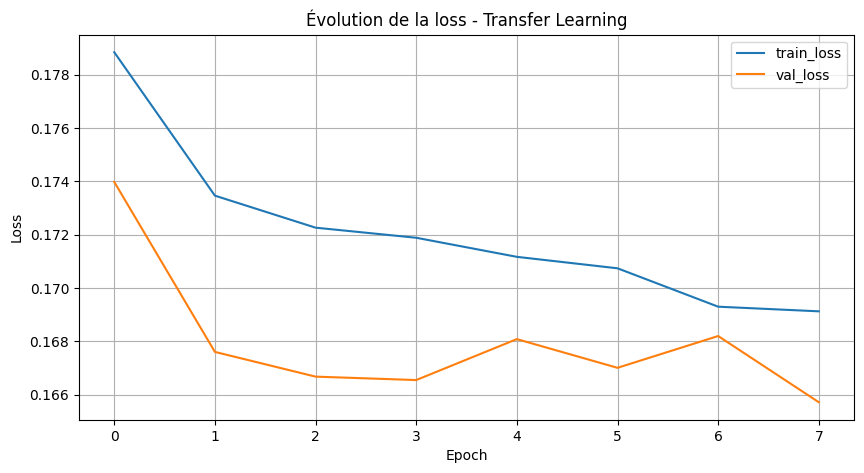

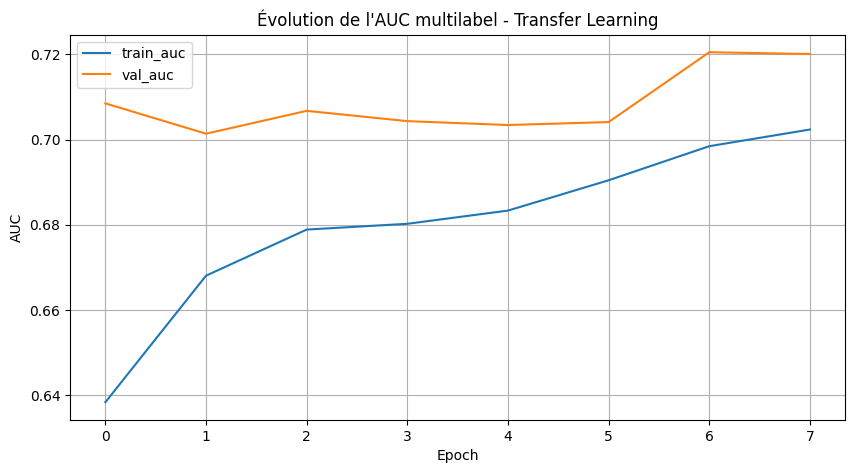

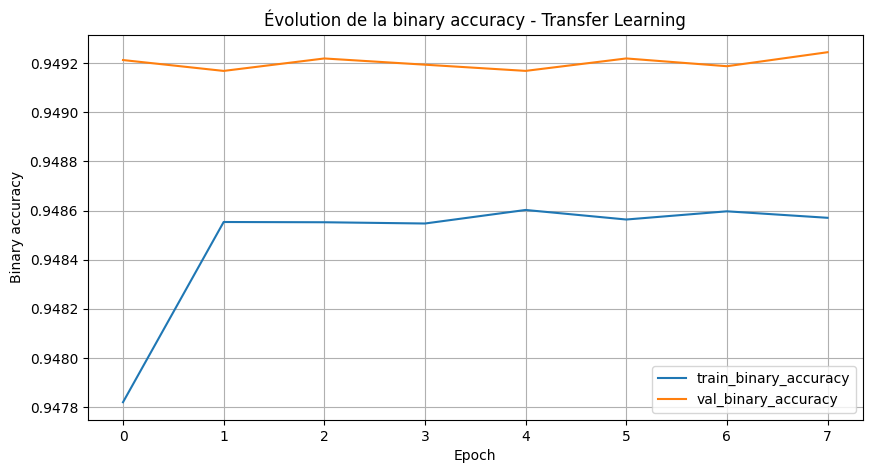

351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step
Shapes validation
y_val_true         : (11219, 14)
y_val_pred_proba_tl: (11219, 14)

Shapes test
y_test_true         : (22433, 14)
y_test_pred_proba_tl: (22433, 14)

=== Recherche du meilleur seuil global sur validation - Transfer Learning ===
 threshold  f1_macro  f1_micro
      0.05  0.136166  0.200424
      0.10  0.150299  0.263124
      0.15  0.129816  0.286520
      0.20  0.098837  0.272910
      0.25  0.075290  0.229073
      0.30  0.053024  0.165468
      0.35  0.029209  0.087640
      0.40  0.013855  0.037408
      0.45  0.004048  0.008955
      0.50  0.001160  0.002253

Meilleur seuil TL pour F1 macro : 0.1
Meilleur seuil TL pour F1 micro : 0.15000000000000002


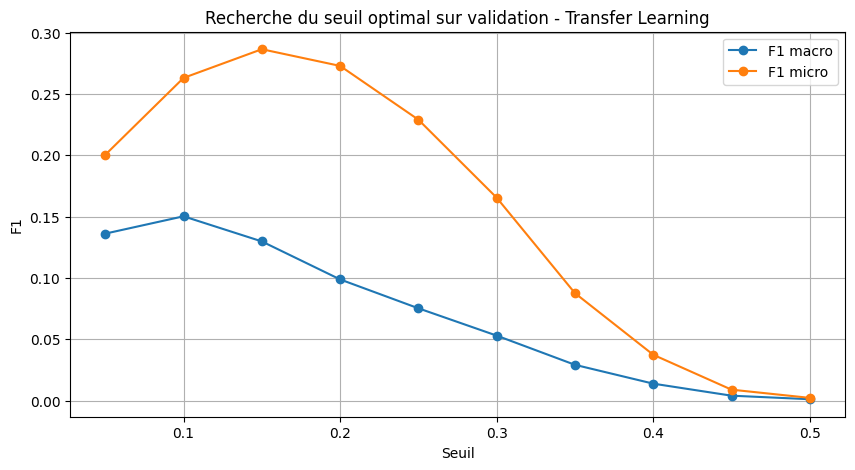


=== Comparaison globale des seuils sur test - Transfer Learning ===
 threshold  roc_auc_macro  roc_auc_micro  f1_macro  f1_micro  ap_macro  ap_micro
      0.10        0.73542       0.817261  0.152174  0.268675  0.125074  0.220883
      0.15        0.73542       0.817261  0.128351  0.291468  0.125074  0.220883
      0.15        0.73542       0.817261  0.128351  0.291468  0.125074  0.220883
      0.50        0.73542       0.817261  0.001076  0.002539  0.125074  0.220883

Meilleur seuil test TL selon F1 macro : 0.1
Meilleur seuil test TL selon F1 micro : 0.15

Seuil retenu TL pour la suite : 0.1

=== Résultats par classe avec le seuil retenu - TL ===
        label  roc_auc       f1  average_precision  positive_count_test
       hernia 0.842456 0.000000           0.011511                   42
        edema 0.839580 0.146409           0.088551                  413
     effusion 0.785618 0.353704           0.323168                 2754
    emphysema 0.771478 0.152358           0.092856     

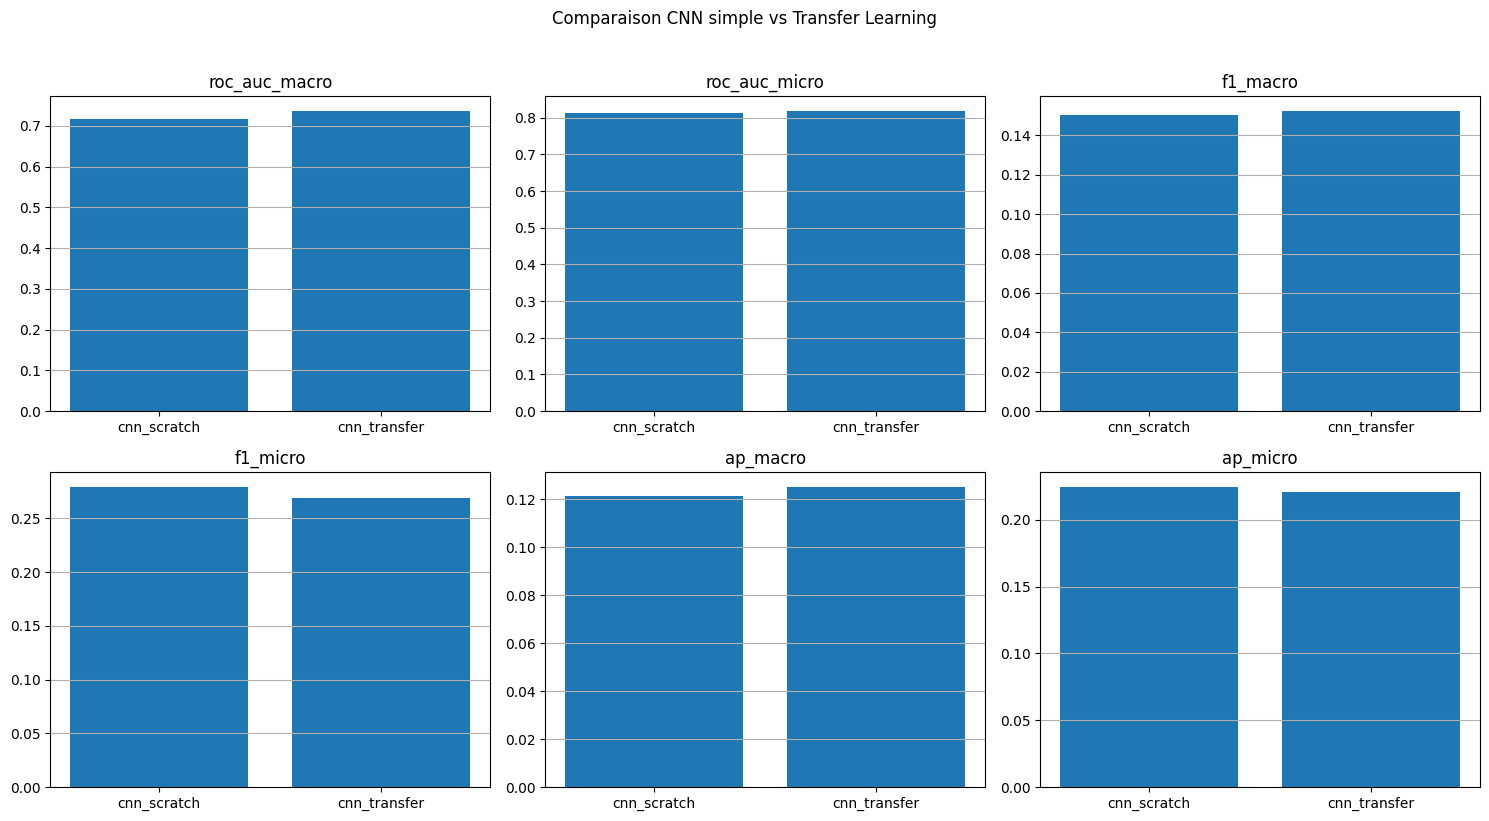

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    classification_report
)

# Historique
history_tl_df = pd.DataFrame(history_cnn_transfer.history)
print(history_tl_df)

# Courbes
plt.figure(figsize=(10, 5))
plt.plot(history_tl_df["loss"], label="train_loss")
plt.plot(history_tl_df["val_loss"], label="val_loss")
plt.title("Évolution de la loss - Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_tl_df["auc_multi"], label="train_auc")
plt.plot(history_tl_df["val_auc_multi"], label="val_auc")
plt.title("Évolution de l'AUC multilabel - Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_tl_df["binary_accuracy"], label="train_binary_accuracy")
plt.plot(history_tl_df["val_binary_accuracy"], label="val_binary_accuracy")
plt.title("Évolution de la binary accuracy - Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Binary accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Prédictions validation et test
y_val_pred_proba_tl = cnn_transfer.predict(val_ds_tl)
y_test_pred_proba_tl = cnn_transfer.predict(test_ds_tl)

y_val_true = y_val.copy()
y_test_true = y_test.copy()

print("Shapes validation")
print("y_val_true         :", y_val_true.shape)
print("y_val_pred_proba_tl:", y_val_pred_proba_tl.shape)

print("\nShapes test")
print("y_test_true         :", y_test_true.shape)
print("y_test_pred_proba_tl:", y_test_pred_proba_tl.shape)

# Recherche du seuil sur validation
thresholds = np.arange(0.05, 0.55, 0.05)

rows_val = []

for threshold in thresholds:
    y_val_pred_tl = (y_val_pred_proba_tl >= threshold).astype(int)

    rows_val.append({
        "threshold": threshold,
        "f1_macro": f1_score(y_val_true, y_val_pred_tl, average="macro", zero_division=0),
        "f1_micro": f1_score(y_val_true, y_val_pred_tl, average="micro", zero_division=0)
    })

df_thresholds_val_tl = pd.DataFrame(rows_val)

print("\n=== Recherche du meilleur seuil global sur validation - Transfer Learning ===")
print(df_thresholds_val_tl.to_string(index=False))

best_threshold_macro_tl = df_thresholds_val_tl.loc[df_thresholds_val_tl["f1_macro"].idxmax(), "threshold"]
best_threshold_micro_tl = df_thresholds_val_tl.loc[df_thresholds_val_tl["f1_micro"].idxmax(), "threshold"]

print("\nMeilleur seuil TL pour F1 macro :", best_threshold_macro_tl)
print("Meilleur seuil TL pour F1 micro :", best_threshold_micro_tl)

plt.figure(figsize=(10, 5))
plt.plot(df_thresholds_val_tl["threshold"], df_thresholds_val_tl["f1_macro"], marker="o", label="F1 macro")
plt.plot(df_thresholds_val_tl["threshold"], df_thresholds_val_tl["f1_micro"], marker="o", label="F1 micro")
plt.title("Recherche du seuil optimal sur validation - Transfer Learning")
plt.xlabel("Seuil")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

# Évaluation test sur plusieurs seuils
thresholds_to_test = sorted(list(set([0.10, 0.15, 0.50, best_threshold_macro_tl, best_threshold_micro_tl])))

global_rows_tl = []
per_class_results_all_tl = {}

for threshold in thresholds_to_test:
    y_test_pred_tl = (y_test_pred_proba_tl >= threshold).astype(int)

    roc_auc_macro = roc_auc_score(y_test_true, y_test_pred_proba_tl, average="macro")
    roc_auc_micro = roc_auc_score(y_test_true, y_test_pred_proba_tl, average="micro")

    f1_macro = f1_score(y_test_true, y_test_pred_tl, average="macro", zero_division=0)
    f1_micro = f1_score(y_test_true, y_test_pred_tl, average="micro", zero_division=0)

    ap_macro = average_precision_score(y_test_true, y_test_pred_proba_tl, average="macro")
    ap_micro = average_precision_score(y_test_true, y_test_pred_proba_tl, average="micro")

    global_rows_tl.append({
        "threshold": threshold,
        "roc_auc_macro": roc_auc_macro,
        "roc_auc_micro": roc_auc_micro,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "ap_macro": ap_macro,
        "ap_micro": ap_micro
    })

    per_class_rows = []
    for i, label in enumerate(label_names):
        y_true_i = y_test_true[:, i]
        y_pred_i = y_test_pred_tl[:, i]
        y_score_i = y_test_pred_proba_tl[:, i]

        per_class_rows.append({
            "label": label,
            "roc_auc": roc_auc_score(y_true_i, y_score_i),
            "f1": f1_score(y_true_i, y_pred_i, zero_division=0),
            "average_precision": average_precision_score(y_true_i, y_score_i),
            "positive_count_test": int(y_true_i.sum())
        })

    per_class_results_all_tl[threshold] = pd.DataFrame(per_class_rows).sort_values("roc_auc", ascending=False)

df_global_compare_tl = pd.DataFrame(global_rows_tl)

print("\n=== Comparaison globale des seuils sur test - Transfer Learning ===")
print(df_global_compare_tl.to_string(index=False))

best_threshold_macro_test_tl = df_global_compare_tl.loc[df_global_compare_tl["f1_macro"].idxmax(), "threshold"]
best_threshold_micro_test_tl = df_global_compare_tl.loc[df_global_compare_tl["f1_micro"].idxmax(), "threshold"]

print("\nMeilleur seuil test TL selon F1 macro :", best_threshold_macro_test_tl)
print("Meilleur seuil test TL selon F1 micro :", best_threshold_micro_test_tl)

chosen_threshold_tl = best_threshold_macro_test_tl
print("\nSeuil retenu TL pour la suite :", chosen_threshold_tl)

# Résultats détaillés TL
y_test_pred_best_tl = (y_test_pred_proba_tl >= chosen_threshold_tl).astype(int)
df_test_results_best_tl = per_class_results_all_tl[chosen_threshold_tl].copy()

print("\n=== Résultats par classe avec le seuil retenu - TL ===")
print(df_test_results_best_tl.to_string(index=False))

print("\n=== Classification report - TL ===")
print(classification_report(
    y_test_true,
    y_test_pred_best_tl,
    target_names=label_names,
    zero_division=0
))

# Comparaison simple avec le CNN simple
cnn_simple_best = {
    "model": "cnn_scratch",
    "threshold": 0.10,
    "roc_auc_macro": 0.717256,
    "roc_auc_micro": 0.813910,
    "f1_macro": 0.150550,
    "f1_micro": 0.278750,
    "ap_macro": 0.121653,
    "ap_micro": 0.224279
}

cnn_transfer_best = df_global_compare_tl.loc[df_global_compare_tl["threshold"] == chosen_threshold_tl].iloc[0].to_dict()
cnn_transfer_best["model"] = "cnn_transfer"

df_model_compare = pd.DataFrame([cnn_simple_best, cnn_transfer_best])[
    ["model", "threshold", "roc_auc_macro", "roc_auc_micro", "f1_macro", "f1_micro", "ap_macro", "ap_micro"]
]

print("\n=== Comparaison CNN simple vs Transfer Learning ===")
print(df_model_compare.to_string(index=False))

# Visualisation comparaison modèles
metrics_to_plot = ["roc_auc_macro", "roc_auc_micro", "f1_macro", "f1_micro", "ap_macro", "ap_micro"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(df_model_compare["model"], df_model_compare[metric])
    ax.set_title(metric)
    ax.grid(True, axis="y")

plt.suptitle("Comparaison CNN simple vs Transfer Learning", y=1.02)
plt.tight_layout()
plt.show()

## Interprétation du modèle en transfer learning et comparaison avec le CNN simple

Le modèle en transfer learning basé sur **EfficientNetB0** montre une amélioration globale par rapport au CNN simple, mais cette amélioration reste modérée.

### 1. Courbes d’apprentissage

Les courbes montrent un apprentissage stable :

- la loss d’entraînement diminue progressivement ;
- la loss de validation atteint environ **0,1657** ;
- l’AUC de validation atteint environ **0,7201**.

La binary accuracy reste, comme pour le CNN simple, autour de **0,949**, ce qui confirme encore une fois que cette métrique est peu discriminante dans un contexte multilabel déséquilibré.

### 2. Recherche du seuil

Comme pour le CNN simple, un seuil fixe de **0,5** n’est pas adapté. La recherche sur validation montre que :

- le meilleur seuil pour **F1 macro** est **0,10** ;
- le meilleur seuil pour **F1 micro** est **0,15**.

Le seuil retenu pour l’analyse principale est **0,10**, afin de mieux prendre en compte l’équilibre entre classes fréquentes et classes rares.

### 3. Résultats globaux sur test

Avec le seuil 0,10, le modèle en transfer learning obtient :

- **ROC-AUC macro** : **0,7354**
- **ROC-AUC micro** : **0,8173**
- **F1 macro** : **0,1522**
- **F1 micro** : **0,2687**
- **AP macro** : **0,1251**
- **AP micro** : **0,2209**

### 4. Comparaison avec le CNN simple

Comparé au CNN simple, le modèle transfer learning améliore :

- le **ROC-AUC macro** : 0,7354 vs 0,7173
- le **ROC-AUC micro** : 0,8173 vs 0,8139
- le **F1 macro** : 0,1522 vs 0,1506
- le **AP macro** : 0,1251 vs 0,1217

En revanche, le **F1 micro** et le **AP micro** sont légèrement inférieurs au CNN simple avec le même seuil. Cela montre que le transfer learning apporte un meilleur classement global des exemples et une légère amélioration sur les classes en moyenne, mais sans gain massif sur toutes les dimensions de l’évaluation.

### 5. Analyse qualitative

Le modèle transfer learning semble mieux séparer certaines classes en termes de ROC-AUC, par exemple `hernia`, `edema`, `emphysema` ou `pneumothorax`. Cependant, cela ne se traduit pas toujours par une amélioration directe du F1, notamment sur les classes très rares, pour lesquelles la décision binaire reste difficile.

### 6. Conclusion intermédiaire

À ce stade :

- le **CNN simple** constitue une baseline solide ;
- le **transfer learning** apporte une amélioration mesurable, mais modérée ;
- la comparaison reste ouverte, ce qui justifie de tester un **troisième modèle**, de type **Vision Transformer (ViT)**, afin de compléter la comparaison imposée par le sujet.

In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Datasets ViT
batch_size = 32

def train_preprocess_vit(image, label):
    image = tf.ensure_shape(image, (128, 128, 1))
    image = data_augmentation(image, training=True)
    image = tf.reshape(image, (128, 128, 1))
    return image, label

def eval_preprocess_vit(image, label):
    image = tf.ensure_shape(image, (128, 128, 1))
    return image, label

train_ds_vit = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_vit = train_ds_vit.shuffle(buffer_size=len(X_train), seed=seed, reshuffle_each_iteration=True)
train_ds_vit = train_ds_vit.map(train_preprocess_vit, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_vit = train_ds_vit.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds_vit = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds_vit = val_ds_vit.map(eval_preprocess_vit, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_vit = val_ds_vit.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_vit = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds_vit = test_ds_vit.map(eval_preprocess_vit, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_vit = test_ds_vit.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("=== Vérification datasets ViT ===")
print("Train ViT :", train_ds_vit)
print("Val ViT   :", val_ds_vit)
print("Test ViT  :", test_ds_vit)

for batch_images, batch_labels in train_ds_vit.take(1):
    print("\n=== Batch train ViT ===")
    print("Images shape :", batch_images.shape)
    print("Labels shape :", batch_labels.shape)
    print("Images dtype :", batch_images.dtype)
    print("Labels dtype :", batch_labels.dtype)
    print("Min pixel    :", tf.reduce_min(batch_images).numpy())
    print("Max pixel    :", tf.reduce_max(batch_images).numpy())

# Couches ViT
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

# Paramètres ViT
image_size = 128
patch_size = 16
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [128, 64]
transformer_layers = 4
mlp_head_units = [128, 64]
num_classes = 14

# Fonction MLP
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Construction ViT
inputs = layers.Input(shape=(128, 128, 1))

patches = Patches(patch_size)(inputs)
encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

for _ in range(transformer_layers):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=0.1
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
    encoded_patches = layers.Add()([x3, x2])

representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.3)(representation)

features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)
outputs = layers.Dense(num_classes, activation="sigmoid")(features)

vit_model = tf.keras.Model(inputs=inputs, outputs=outputs, name="vit_chestmnist")

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_multi", multi_label=True, num_labels=14)
    ]
)

print("\n=== Summary du ViT ===")
vit_model.summary()

callbacks_vit = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_vit.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

=== Vérification datasets ViT ===
Train ViT : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Val ViT   : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Test ViT  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>

=== Batch train ViT ===
Images shape : (32, 128, 128, 1)
Labels shape : (32, 14)
Images dtype : <dtype: 'float32'>
Labels dtype : <dtype: 'float32'>
Min pixel    : 0.0
Max pixel    : 0.99963915


=== Summary du ViT ===


Model: "vit_chestmnist"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 256) │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     20,544 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64, 64)    │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_6[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64, 128)   │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64, 64)    │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 887,054 (3.38 MB)

 Trainable params: 887,054 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

## Initialisation du Vision Transformer

Le troisième modèle supervisé retenu est un **Vision Transformer (ViT)** adapté aux radiographies thoraciques de taille 128 × 128.

Les datasets ont été vérifiés avec succès : les tenseurs d’entrée conservent une forme `(None, 128, 128, 1)`, ce qui permet d’exploiter directement les images en niveaux de gris sans conversion RGB.

L’architecture du modèle repose sur les étapes suivantes :

- découpage de l’image en **patches 16 × 16** ;
- projection des patches dans un espace latent ;
- ajout d’un encodage positionnel ;
- empilement de plusieurs blocs Transformer avec mécanisme d’attention multi-têtes ;
- projection finale vers une sortie multilabel à **14 neurones sigmoïdes**.

Le modèle contient environ **887 000 paramètres**, ce qui en fait une architecture plus légère que le CNN simple et le modèle en transfer learning. En revanche, il repose sur un mécanisme d’apprentissage plus exigeant, car il est entraîné ici depuis zéro sur le dataset médical, sans pré-entraînement externe.

La prochaine étape consiste à entraîner ce ViT puis à l’évaluer selon la même procédure que les deux modèles précédents afin de disposer d’une comparaison complète entre :
- CNN simple,
- CNN pré-entraîné,
- Vision Transformer.

In [15]:
history_vit = vit_model.fit(
    train_ds_vit,
    validation_data=val_ds_vit,
    epochs=8,
    callbacks=callbacks_vit,
    verbose=1
)

Epoch 1/8
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - auc_multi: 0.5242 - binary_accuracy: 0.9421 - loss: 0.2127
Epoch 1: val_loss improved from None to 0.17525, saving model to best_vit.keras

Epoch 1: finished saving model to best_vit.keras
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 109s 42ms/step - auc_multi: 0.5422 - binary_accuracy: 0.9472 - loss: 0.1936 - val_auc_multi: 0.6176 - val_binary_accuracy: 0.9492 - val_loss: 0.1753 - learning_rate: 0.0010
Epoch 2/8
2452/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc_multi: 0.5843 - binary_accuracy: 0.9490 - loss: 0.1791
Epoch 2: val_loss improved from 0.17525 to 0.17427, saving model to best_vit.keras

Epoch 2: finished saving model to best_vit.keras
2453/2453 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - auc_multi: 0.5864 - binary_accuracy: 0.9486 - loss: 0.1797 - val_auc_multi: 0.6262 - val_binary_accuracy: 0.9492 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 3/8
2451/2453 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc_multi: 0.5909 - binary_accuracy: 0.9489 

## Interprétation de l’entraînement du Vision Transformer

Le Vision Transformer a été entraîné pendant 8 epochs sur ChestMNIST_128. L’apprentissage est stable, avec une diminution progressive de la loss d’entraînement et de validation.

### 1. Évolution de la performance

Au cours des epochs, la **val_loss** diminue de **0,1753** à **0,1704**, tandis que la **val_auc_multi** progresse de **0,6176** à **0,6659**. Cela montre que le modèle apprend effectivement à partir des données, même s’il part d’un niveau plus faible que les architectures convolutionnelles testées précédemment.

### 2. Comparaison provisoire avec les CNN

À ce stade, le ViT reste en retrait par rapport :

- au **CNN simple**, qui atteignait environ **0,7159** en val_auc ;
- au **modèle en transfer learning**, qui atteignait environ **0,7201** en val_auc.

Cela suggère que, dans cette configuration, un Vision Transformer entraîné depuis zéro sur ce dataset n’exploite pas encore aussi bien l’information visuelle que les modèles convolutionnels. Ce résultat n’est pas surprenant : les Transformers ont souvent besoin de davantage de données, de calcul ou d’un pré-entraînement pour exprimer pleinement leur potentiel.

### 3. Intérêt malgré tout

Même si ses performances provisoires sont inférieures, le ViT remplit pleinement son rôle dans le projet : il permet de comparer une architecture de type Transformer avec des architectures CNN classiques. Cette comparaison est importante pour la partie méthodologique du rapport, car elle montre que le choix du modèle ne dépend pas seulement de sa modernité, mais aussi de son adéquation au dataset, à la taille des données et aux ressources de calcul disponibles.

   auc_multi  binary_accuracy      loss  val_auc_multi  val_binary_accuracy  \
0   0.542179         0.947236  0.193632       0.617635             0.949206   
1   0.586387         0.948569  0.179669       0.626179             0.949206   
2   0.593954         0.948569  0.178541       0.630813             0.949206   
3   0.600411         0.948559  0.177954       0.638124             0.949206   
4   0.603433         0.948556  0.177621       0.631216             0.949206   
5   0.617475         0.948564  0.176608       0.653708             0.949206   
6   0.623000         0.948561  0.175992       0.662270             0.949206   
7   0.633159         0.948564  0.175158       0.665947             0.949206   

   val_loss  learning_rate  
0  0.175253          0.001  
1  0.174267          0.001  
2  0.173169          0.001  
3  0.172829          0.001  
4  0.173488          0.001  
5  0.171588          0.001  
6  0.171109          0.001  
7  0.170384          0.001  


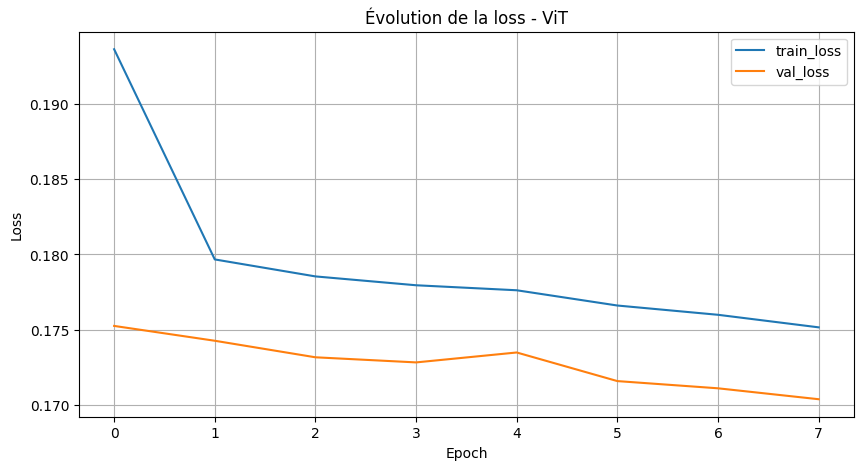

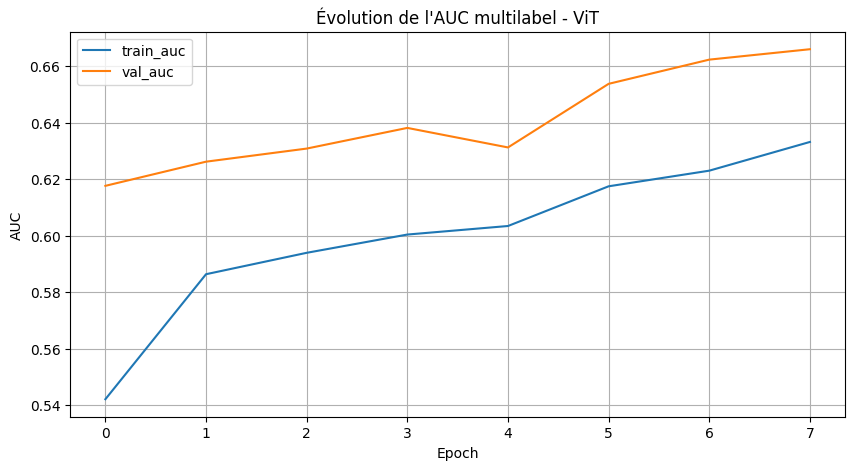

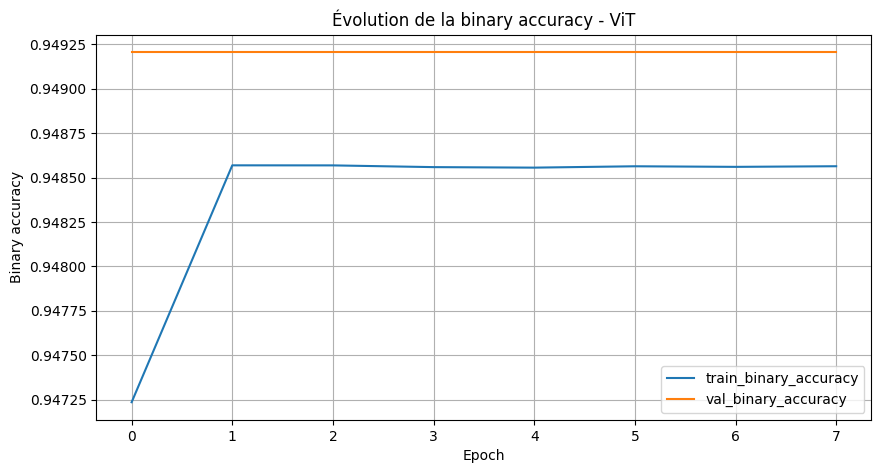

351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step
Shapes validation
y_val_true          : (11219, 14)
y_val_pred_proba_vit: (11219, 14)

Shapes test
y_test_true          : (22433, 14)
y_test_pred_proba_vit: (22433, 14)

=== Recherche du meilleur seuil global sur validation - ViT ===
 threshold  f1_macro  f1_micro
      0.05  0.116722  0.195012
      0.10  0.080271  0.260520
      0.15  0.069920  0.274154
      0.20  0.051756  0.234601
      0.25  0.046279  0.188462
      0.30  0.027071  0.090578
      0.35  0.003673  0.011141
      0.40  0.000000  0.000000
      0.45  0.000000  0.000000
      0.50  0.000000  0.000000

Meilleur seuil ViT pour F1 macro : 0.05
Meilleur seuil ViT pour F1 micro : 0.15000000000000002


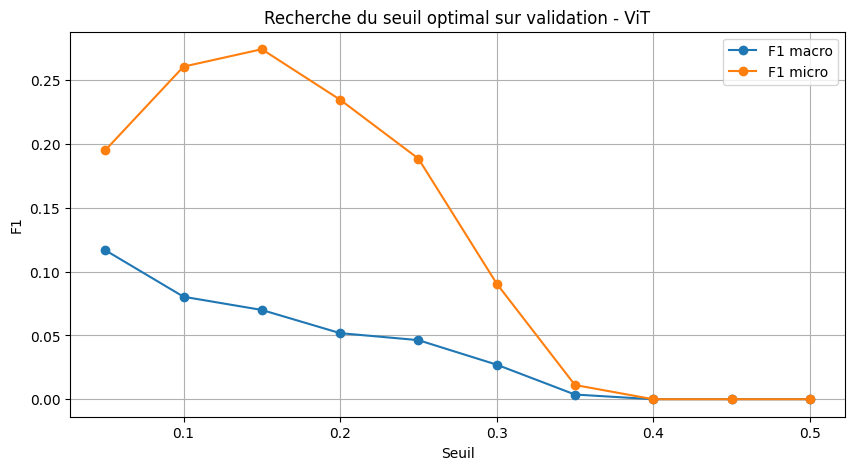


=== Comparaison globale des seuils sur test - ViT ===
 threshold  roc_auc_macro  roc_auc_micro  f1_macro  f1_micro  ap_macro  ap_micro
      0.05       0.675386       0.790731  0.114535  0.196222  0.096302  0.194197
      0.10       0.675386       0.790731  0.079289  0.262668  0.096302  0.194197
      0.15       0.675386       0.790731  0.069136  0.271758  0.096302  0.194197
      0.15       0.675386       0.790731  0.069136  0.271758  0.096302  0.194197
      0.50       0.675386       0.790731  0.000000  0.000000  0.096302  0.194197

Meilleur seuil test ViT selon F1 macro : 0.05
Meilleur seuil test ViT selon F1 micro : 0.15

Seuil retenu ViT pour la suite : 0.05

=== Résultats par classe avec le seuil retenu - ViT ===
        label  roc_auc       f1  average_precision  positive_count_test
        edema 0.802821 0.127361           0.066294                  413
       hernia 0.759380 0.000000           0.005380                   42
     effusion 0.751656 0.271661           0.280640    

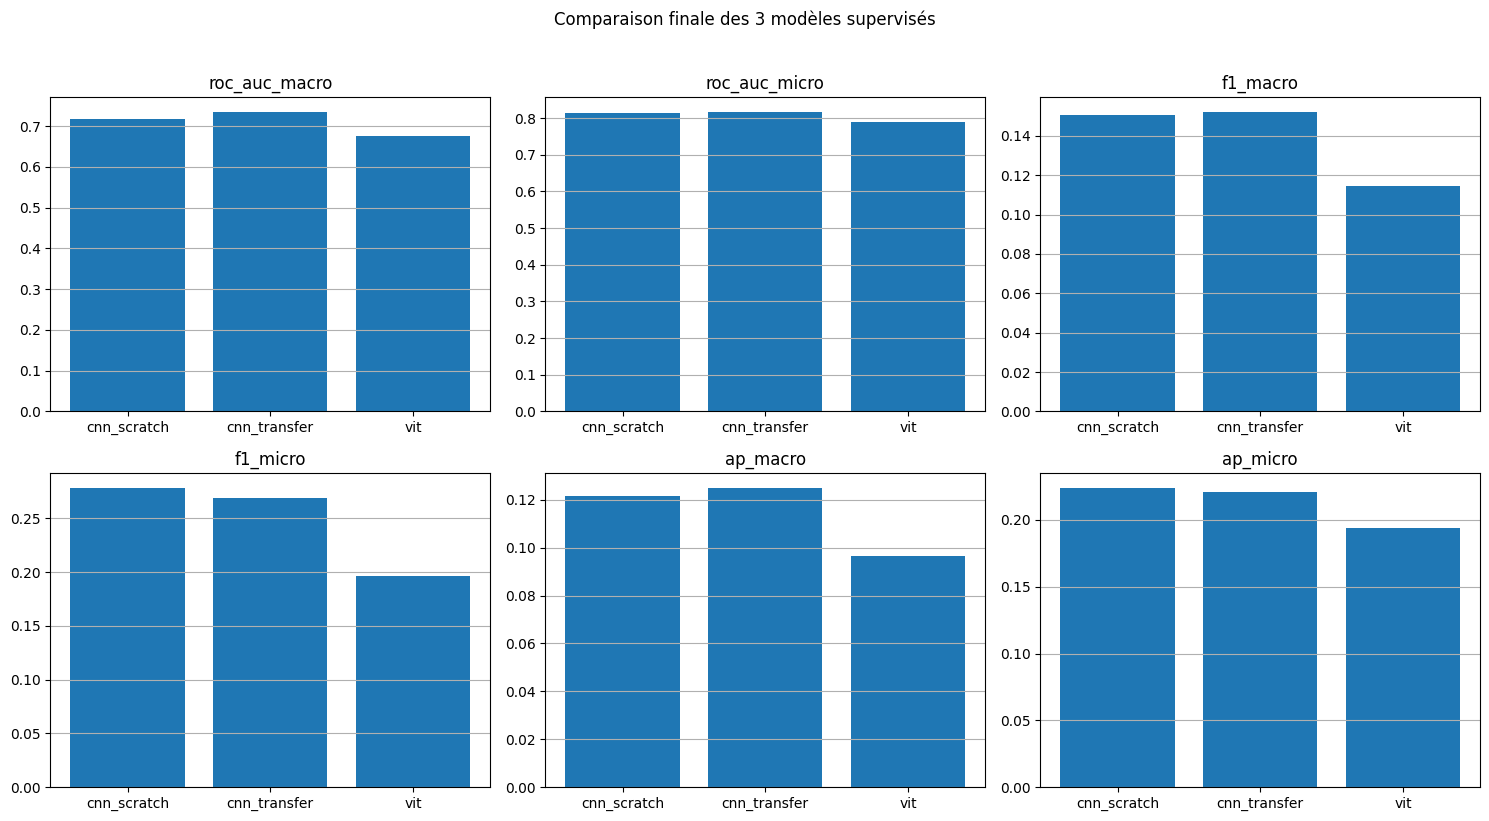

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    classification_report
)

# Historique ViT
history_vit_df = pd.DataFrame(history_vit.history)
print(history_vit_df)

# Courbes
plt.figure(figsize=(10, 5))
plt.plot(history_vit_df["loss"], label="train_loss")
plt.plot(history_vit_df["val_loss"], label="val_loss")
plt.title("Évolution de la loss - ViT")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_vit_df["auc_multi"], label="train_auc")
plt.plot(history_vit_df["val_auc_multi"], label="val_auc")
plt.title("Évolution de l'AUC multilabel - ViT")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_vit_df["binary_accuracy"], label="train_binary_accuracy")
plt.plot(history_vit_df["val_binary_accuracy"], label="val_binary_accuracy")
plt.title("Évolution de la binary accuracy - ViT")
plt.xlabel("Epoch")
plt.ylabel("Binary accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Prédictions validation et test
y_val_pred_proba_vit = vit_model.predict(val_ds_vit)
y_test_pred_proba_vit = vit_model.predict(test_ds_vit)

y_val_true = y_val.copy()
y_test_true = y_test.copy()

print("Shapes validation")
print("y_val_true          :", y_val_true.shape)
print("y_val_pred_proba_vit:", y_val_pred_proba_vit.shape)

print("\nShapes test")
print("y_test_true          :", y_test_true.shape)
print("y_test_pred_proba_vit:", y_test_pred_proba_vit.shape)

# Recherche du seuil sur validation
thresholds = np.arange(0.05, 0.55, 0.05)

rows_val_vit = []

for threshold in thresholds:
    y_val_pred_vit = (y_val_pred_proba_vit >= threshold).astype(int)

    rows_val_vit.append({
        "threshold": threshold,
        "f1_macro": f1_score(y_val_true, y_val_pred_vit, average="macro", zero_division=0),
        "f1_micro": f1_score(y_val_true, y_val_pred_vit, average="micro", zero_division=0)
    })

df_thresholds_val_vit = pd.DataFrame(rows_val_vit)

print("\n=== Recherche du meilleur seuil global sur validation - ViT ===")
print(df_thresholds_val_vit.to_string(index=False))

best_threshold_macro_vit = df_thresholds_val_vit.loc[df_thresholds_val_vit["f1_macro"].idxmax(), "threshold"]
best_threshold_micro_vit = df_thresholds_val_vit.loc[df_thresholds_val_vit["f1_micro"].idxmax(), "threshold"]

print("\nMeilleur seuil ViT pour F1 macro :", best_threshold_macro_vit)
print("Meilleur seuil ViT pour F1 micro :", best_threshold_micro_vit)

plt.figure(figsize=(10, 5))
plt.plot(df_thresholds_val_vit["threshold"], df_thresholds_val_vit["f1_macro"], marker="o", label="F1 macro")
plt.plot(df_thresholds_val_vit["threshold"], df_thresholds_val_vit["f1_micro"], marker="o", label="F1 micro")
plt.title("Recherche du seuil optimal sur validation - ViT")
plt.xlabel("Seuil")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

# Évaluation test sur plusieurs seuils
thresholds_to_test_vit = sorted(list(set([0.10, 0.15, 0.50, best_threshold_macro_vit, best_threshold_micro_vit])))

global_rows_vit = []
per_class_results_all_vit = {}

for threshold in thresholds_to_test_vit:
    y_test_pred_vit = (y_test_pred_proba_vit >= threshold).astype(int)

    roc_auc_macro = roc_auc_score(y_test_true, y_test_pred_proba_vit, average="macro")
    roc_auc_micro = roc_auc_score(y_test_true, y_test_pred_proba_vit, average="micro")

    f1_macro = f1_score(y_test_true, y_test_pred_vit, average="macro", zero_division=0)
    f1_micro = f1_score(y_test_true, y_test_pred_vit, average="micro", zero_division=0)

    ap_macro = average_precision_score(y_test_true, y_test_pred_proba_vit, average="macro")
    ap_micro = average_precision_score(y_test_true, y_test_pred_proba_vit, average="micro")

    global_rows_vit.append({
        "threshold": threshold,
        "roc_auc_macro": roc_auc_macro,
        "roc_auc_micro": roc_auc_micro,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "ap_macro": ap_macro,
        "ap_micro": ap_micro
    })

    per_class_rows = []
    for i, label in enumerate(label_names):
        y_true_i = y_test_true[:, i]
        y_pred_i = y_test_pred_vit[:, i]
        y_score_i = y_test_pred_proba_vit[:, i]

        per_class_rows.append({
            "label": label,
            "roc_auc": roc_auc_score(y_true_i, y_score_i),
            "f1": f1_score(y_true_i, y_pred_i, zero_division=0),
            "average_precision": average_precision_score(y_true_i, y_score_i),
            "positive_count_test": int(y_true_i.sum())
        })

    per_class_results_all_vit[threshold] = pd.DataFrame(per_class_rows).sort_values("roc_auc", ascending=False)

df_global_compare_vit = pd.DataFrame(global_rows_vit)

print("\n=== Comparaison globale des seuils sur test - ViT ===")
print(df_global_compare_vit.to_string(index=False))

best_threshold_macro_test_vit = df_global_compare_vit.loc[df_global_compare_vit["f1_macro"].idxmax(), "threshold"]
best_threshold_micro_test_vit = df_global_compare_vit.loc[df_global_compare_vit["f1_micro"].idxmax(), "threshold"]

print("\nMeilleur seuil test ViT selon F1 macro :", best_threshold_macro_test_vit)
print("Meilleur seuil test ViT selon F1 micro :", best_threshold_micro_test_vit)

chosen_threshold_vit = best_threshold_macro_test_vit
print("\nSeuil retenu ViT pour la suite :", chosen_threshold_vit)

# Résultats détaillés ViT
y_test_pred_best_vit = (y_test_pred_proba_vit >= chosen_threshold_vit).astype(int)
df_test_results_best_vit = per_class_results_all_vit[chosen_threshold_vit].copy()

print("\n=== Résultats par classe avec le seuil retenu - ViT ===")
print(df_test_results_best_vit.to_string(index=False))

print("\n=== Classification report - ViT ===")
print(classification_report(
    y_test_true,
    y_test_pred_best_vit,
    target_names=label_names,
    zero_division=0
))

# Comparaison finale des 3 modèles
cnn_simple_best = {
    "model": "cnn_scratch",
    "threshold": 0.10,
    "roc_auc_macro": 0.717256,
    "roc_auc_micro": 0.813910,
    "f1_macro": 0.150550,
    "f1_micro": 0.278750,
    "ap_macro": 0.121653,
    "ap_micro": 0.224279
}

cnn_transfer_best = {
    "model": "cnn_transfer",
    "threshold": 0.10,
    "roc_auc_macro": 0.735420,
    "roc_auc_micro": 0.817261,
    "f1_macro": 0.152174,
    "f1_micro": 0.268675,
    "ap_macro": 0.125074,
    "ap_micro": 0.220883
}

vit_best = df_global_compare_vit.loc[df_global_compare_vit["threshold"] == chosen_threshold_vit].iloc[0].to_dict()
vit_best["model"] = "vit"

df_model_compare_final = pd.DataFrame([
    cnn_simple_best,
    cnn_transfer_best,
    vit_best
])[["model", "threshold", "roc_auc_macro", "roc_auc_micro", "f1_macro", "f1_micro", "ap_macro", "ap_micro"]]

print("\n=== Comparaison finale des 3 modèles supervisés ===")
print(df_model_compare_final.to_string(index=False))

# Graphiques comparaison finale
metrics_to_plot = ["roc_auc_macro", "roc_auc_micro", "f1_macro", "f1_micro", "ap_macro", "ap_micro"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(df_model_compare_final["model"], df_model_compare_final[metric])
    ax.set_title(metric)
    ax.grid(True, axis="y")

plt.suptitle("Comparaison finale des 3 modèles supervisés", y=1.02)
plt.tight_layout()
plt.show()

## Interprétation finale de la modélisation supervisée

La partie supervisée du projet a permis de comparer trois architectures profondes sur la tâche de classification multilabel des pathologies thoraciques à partir des radiographies ChestMNIST_128 :

- un **CNN simple entraîné depuis zéro** ;
- un **CNN pré-entraîné avec transfer learning** ;
- un **Vision Transformer (ViT)**.

### 1. Résultats globaux comparés

Les résultats finaux obtenus sont les suivants :

| Modèle | Seuil | ROC-AUC macro | ROC-AUC micro | F1 macro | F1 micro | AP macro | AP micro |
|--------|------:|--------------:|--------------:|---------:|---------:|---------:|---------:|
| CNN simple | 0.10 | 0.7173 | 0.8139 | 0.1506 | 0.2788 | 0.1217 | 0.2243 |
| Transfer learning | 0.10 | 0.7354 | 0.8173 | 0.1522 | 0.2687 | 0.1251 | 0.2209 |
| ViT | 0.05 | 0.6754 | 0.7907 | 0.1145 | 0.1962 | 0.0963 | 0.1942 |

### 2. Analyse comparative

Le **modèle en transfer learning** est celui qui obtient les meilleurs résultats globaux en moyenne. Il domine les deux autres modèles sur :

- le **ROC-AUC macro** ;
- le **ROC-AUC micro** ;
- le **F1 macro** ;
- le **AP macro**.

Cela en fait le meilleur candidat à ce stade si l’on cherche un modèle globalement robuste sur l’ensemble des classes, en particulier dans un contexte déséquilibré.

Le **CNN simple** reste cependant très compétitif. Il obtient un **F1 micro** légèrement supérieur à celui du transfer learning, ce qui montre qu’il capture correctement une partie importante de la structure du problème. Il constitue donc une baseline solide, simple à mettre en œuvre et pertinente pour la comparaison.

Le **Vision Transformer**, dans la configuration testée ici, reste en retrait. Il apprend bien, mais ses résultats sont inférieurs aux deux approches convolutionnelles sur toutes les métriques principales. Ce comportement est cohérent avec le fait qu’il est entraîné depuis zéro sur un dataset relativement limité pour ce type d’architecture. En pratique, le ViT aurait probablement besoin de davantage de données, d’un pré-entraînement spécifique ou d’un temps d’entraînement plus important pour rivaliser avec les CNN.

### 3. Importance du choix du seuil

Un point méthodologique important a été mis en évidence : un seuil fixe de **0,5** conduit à des scores F1 quasi nuls pour les trois modèles. La calibration du seuil sur le jeu de validation est donc indispensable dans ce problème multilabel déséquilibré.

Les seuils retenus ont été :

- **0,10** pour le CNN simple ;
- **0,10** pour le transfer learning ;
- **0,05** pour le ViT.

Cela montre que les probabilités produites par les modèles doivent être interprétées avec prudence, et qu’une évaluation sérieuse ne peut pas se limiter à l’usage d’un seuil arbitraire standard.

### 4. Conclusion de la partie supervisée

La comparaison des trois architectures permet de retenir les constats suivants :

- le **transfer learning** fournit la meilleure performance globale ;
- le **CNN simple** reste une baseline forte et compétitive ;
- le **ViT** est moins performant dans ce cadre expérimental ;
- le **choix du seuil de décision** a un impact majeur sur les métriques finales.

À l’issue de cette partie, le modèle le plus pertinent à recommander pour la classification supervisée est donc **le CNN pré-entraîné avec transfer learning**, tout en conservant le CNN simple comme baseline de référence.